# Analyse Exploratoire Kickstarter

## Problématique

**Comment tirer parti de la donnée de crowdfunding pour aider les entrepreneurs à atteindre leur Product-Market Fit ?**

C'est l'objet de notre étude qui vise à modéliser les facteurs de sur-performance de plus de 200 000 campagnes Kickstarter afin d'isoler les leviers opérationnels du Product-Market Fit.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("white")

# Charte graphique
plt.rcParams.update({
    'font.family': 'Times New Roman',

    'axes.titlesize': 14,       
    'axes.titleweight': 'bold', 
    'axes.labelsize': 12,      
    'xtick.labelsize': 12,      
    'ytick.labelsize': 12,      
    'legend.fontsize': 10,     
    'font.size': 12,            
    'text.color': '#000000',          
    'axes.titlecolor': '#000000',    
    'axes.labelcolor': '#000000',     
    'xtick.color': '#000000',        
    'ytick.color': '#000000'       
})

kickstarter_df = pd.read_csv('/Users/mariamalaborde/Documents/DataScientest/memoire-2026/data/clean_kickstarter.csv', sep=',', encoding='utf-8')

kickstarter_df.head(3)

,id,name,blurb,state,created_at,launched_at,deadline,duration_days,prep_days,launch_month,...,region,has_video,staff_pick,spotlight,name_len_words,name_len_char,blurb_len_char,blurb_len_words,blurb_density,is_success
0,13583,American Dream # 1 | 31 Pages of Full Color He...,A heroine's first day on the job uncovers a te...,successful,2023-04-02 16:35:40,2024-09-04 13:59:04,2024-11-03 14:59:04,60,520,September,...,Amérique du Nord,True,False,True,12,57,97,17,5.71,True
1,18520,Grandma's are Life,Raising money to help my grandmother recover f...,failed,2016-10-19 12:13:18,2016-10-19 13:32:40,2016-11-18 14:32:40,30,0,October,...,Amérique du Nord,False,False,False,3,18,135,24,5.62,False
2,19685,Pumpkin & Friends: Soft & Silly Plush Pals!,"The cute, soft, and huggable plushies are read...",successful,2024-04-08 19:45:55,2024-05-14 17:31:01,2024-06-28 17:31:01,45,35,May,...,Amérique du Nord,False,False,True,8,43,58,10,5.80,True


In [2]:
kickstarter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201431 entries, 0 to 201430
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      201431 non-null  int64  
 1   name                    201431 non-null  str    
 2   blurb                   201431 non-null  str    
 3   state                   201431 non-null  str    
 4   created_at              201431 non-null  str    
 5   launched_at             201431 non-null  str    
 6   deadline                201431 non-null  str    
 7   duration_days           201431 non-null  int64  
 8   prep_days               201431 non-null  int64  
 9   launch_month            201431 non-null  str    
 10  launch_year             201431 non-null  int64  
 11  goal_eur                201431 non-null  float64
 12  pledged_eur             201431 non-null  float64
 13  percent_funded          201431 non-null  float64
 14  backers_count           201431 

## Performance

### Distribution du succès

--- Nombre de projets par statut ---
state
successful    119596
failed         69900
canceled        9172
live            2763
Name: count, dtype: int64

--- Pourcentage par statut ---
state
successful    59.37
failed        34.70
canceled       4.55
live           1.37
Name: proportion, dtype: float64


/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/3643089135.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='CMRmap')


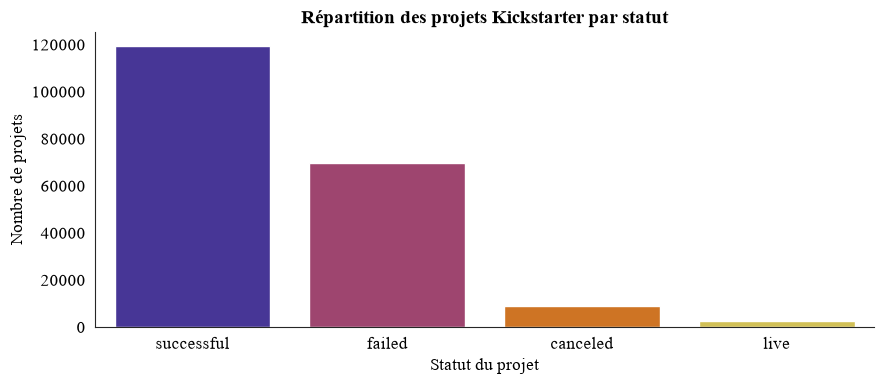

In [3]:
state_counts = kickstarter_df['state'].value_counts()
state_percent = kickstarter_df['state'].value_counts(normalize=True) * 100

print("--- Nombre de projets par statut ---")
print(state_counts)
print("\n--- Pourcentage par statut ---")
print(state_percent.round(2))

plt.figure(figsize=(9, 4))

sns.barplot(x=state_counts.index, y=state_counts.values, palette='CMRmap')

plt.title('Répartition des projets Kickstarter par statut')
plt.xlabel('Statut du projet')
plt.ylabel('Nombre de projets')

sns.despine()
plt.tight_layout()
plt.show()

### Corrélation entre les variables numériques

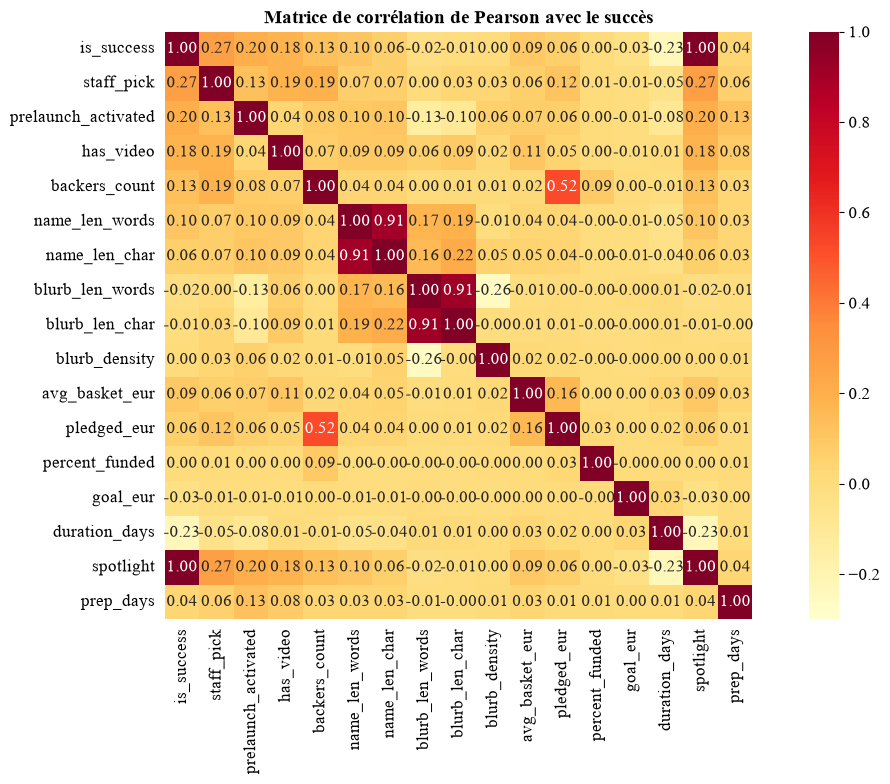

In [ ]:
df_completed = kickstarter_df[kickstarter_df['state'].isin(['successful', 'failed', 'canceled'])].copy()

num_cols = [
    'is_success', 'staff_pick', 'prelaunch_activated', 'has_video', 
    'backers_count', 'name_len_words', 'name_len_char', 'blurb_len_words', 'blurb_len_char', 'blurb_density', 'avg_basket_eur', 
    'pledged_eur', 'percent_funded', 'goal_eur', 'duration_days', 'spotlight', 'prep_days'
]

corr = df_completed[num_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr, 
    annot=True,          
    fmt=".2f",           
    cmap="YlOrRd",  
    vmin=-0.3, vmax=1.0, 
    square=True
)

plt.title("Matrice de corrélation de Pearson")
plt.tight_layout()
plt.show()

D'après cette matrice, les 3 grands moteurs de succès sont :
* `staff_pick` : Preuve sociale et highlight
* `prelaunch_activated` : Une page de pré-lancement a été configurée.
* `has_video` : Une vidéo a été mise en ligne.

En revanche, on a un frein :
* `duration_days` : On peut supposer que plus une campagne est longue, moins il y a ce sentiment d'urgence.

Une autre corrélation à noter, hors-succès :
* Entre `backers_count` et `pledged_eur` : Plus on a de contributeurs, plus le montant récolté est élevé.

### Corrélation entre les variables qualitatives

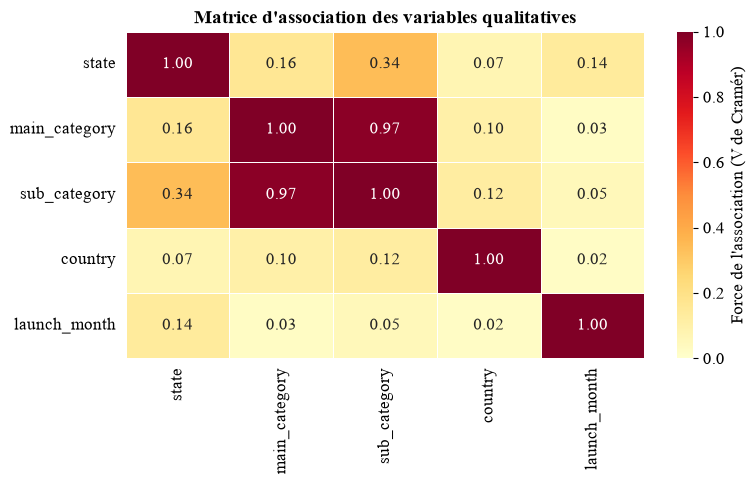

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcule le V de Cramér entre deux variables qualitatives."""
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()
    
    r, c = confusion_matrix.shape
    
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

colonnes_quali = ['state', 'main_category', 'sub_category', 'country', 'launch_month']

df_quali = kickstarter_df[colonnes_quali].dropna().copy()
cramer_matrix = pd.DataFrame(index=colonnes_quali, columns=colonnes_quali)

for col1 in colonnes_quali:
    for col2 in colonnes_quali:
        cramer_matrix.loc[col1, col2] = cramers_v(df_quali[col1], df_quali[col2])

cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cramer_matrix, 
    annot=True,           
    fmt=".2f",             
    cmap="YlOrRd",         
    vmin=0, vmax=1,        
    linewidths=0.5,        
    cbar_kws={'label': 'Force de l\'association (V de Cramér)'}
)

plt.title("Matrice d'association des variables qualitatives")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

D'après cette matrice d'association, la sous-catégorie semble avoir plus d'influence sur le succès que la catégorie principale. En revanche, l'influence du mois de lancement et du pays de lancement est limitée.

## Finances

### Analyse des objectifs financiers
* Existe-t-il un "seuil critique" au-delà duquel le taux de succès chute drastiquement ?
* Comparaison de la médiane de goal_eur entre succès et échecs.

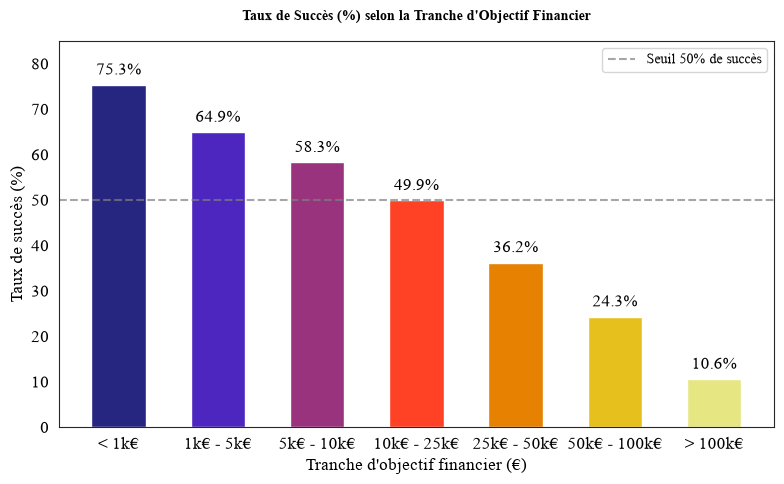

In [ ]:
bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']

df_completed['goal_bin'] = pd.cut(df_completed['goal_eur'], bins=bins_goal, labels=labels_goal)


success_rate = df_completed.groupby('goal_bin', observed=False)['is_success'].mean() * 100


colors = sns.color_palette('CMRmap', len(success_rate))
plt.figure(figsize=(8, 5))

bars = plt.bar(
    success_rate.index, success_rate.values, color=colors, width=0.55
)

plt.title(
    "Taux de Succès (%) selon la tranche d'objectif financier",
    fontsize=10,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Tranche d'objectif financier (€)")
plt.ylabel('Taux de succès (%)')

plt.ylim(0, 85)

plt.axhline(
    50, color='grey', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

for bar in bars:
  height = bar.get_height()
  plt.annotate(
      f'{height:.1f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height + 1.5),
      ha='center',
      va='bottom'
  )

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

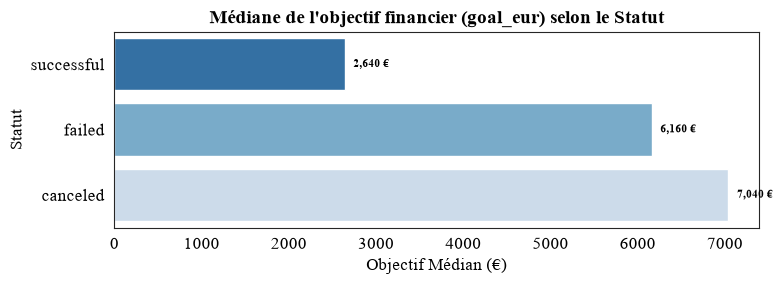

In [ ]:
goal_medians = df_completed.groupby('state')['goal_eur'].median().reindex(['successful', 'failed', 'canceled'])

plt.figure(figsize=(8, 3))
ax = sns.barplot(x=goal_medians.values, y=goal_medians.index, palette='Blues_r', hue=goal_medians.index, legend=False)

plt.title("Médiane de l'objectif financier selon le statut")
plt.xlabel("Objectif financier médian (€)")
plt.ylabel("Statut")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f} €', (width + 100, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

D'après ces deux graphiques, on peut en conclure que plus l'objectif est élevé, moins la campagne a de chances de réussir.

* Les projets demandant moins de 1 000 € réussissent dans 3 cas sur 4 (75,3 %).
* À l'inverse, les projets ambitieux demandant plus de 100 000 € échouent à près de 90 % du temps.
* Il semble exister un seuil aux alentours des 25 000 €. En dessous de 25k€, le taux de succès reste égal ou supérieur à 50 %.
* Au-delà de 25k€, le taux de succès chute brutalement à 36,2 %, puis dégringole.

### Sur-performance et atteinte de l'objectif
* Distribution du taux de financement : détecter les outliers.

In [8]:
def categorize_performance(row):
    if row['state'] in ['failed', 'canceled']:
        return "Non financé <100%"
    
    elif row['state'] == 'live':
        return "En cours"
    
    elif row['state'] == 'successful':
        pf = row['percent_funded']
        if pf < 105:
            return "Tout juste 100-105%"
        elif pf < 200:
            return "Modérée 105-200%"
        elif pf < 500:
            return "Solide 200-500%"
        elif pf < 1000:
            return "Très forte 500-1000%"
        else:
            return "Super-funded >1000%"
    return "Autre"

kickstarter_df['performance_tier'] = kickstarter_df.apply(categorize_performance, axis=1)

print(kickstarter_df['performance_tier'].value_counts().sort_index())

performance_tier
En cours                 2763
Modérée 105-200%        57093
Non financé <100%       79072
Solide 200-500%         17969
Super-funded >1000%     10264
Tout juste 100-105%     26519
Très forte 500-1000%     7751
Name: count, dtype: int64


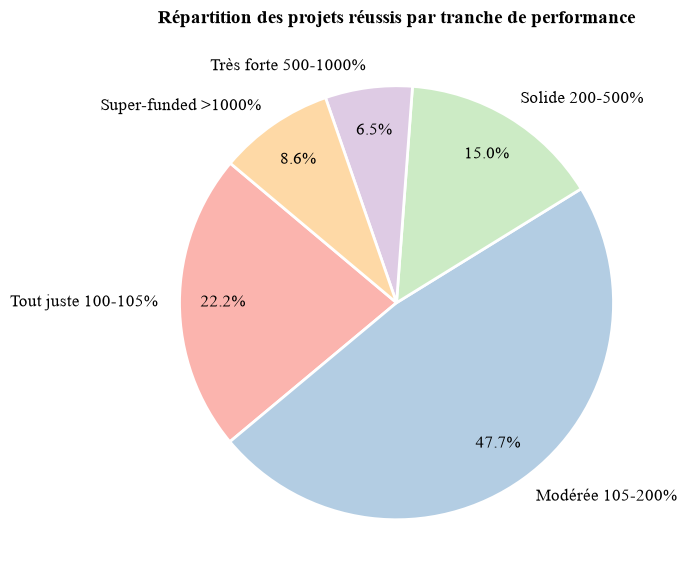

In [52]:
df_success = kickstarter_df[kickstarter_df['state'] == 'successful'].copy()

ordered_tiers = [
    "Tout juste 100-105%",
    "Modérée 105-200%",
    "Solide 200-500%",
    "Très forte 500-1000%",
    "Super-funded >1000%"
]

tier_counts = df_success['performance_tier'].value_counts(normalize=True).reindex(ordered_tiers) * 100

fig, ax = plt.subplots(figsize=(7, 6))

colors = sns.color_palette("Pastel1", len(tier_counts))

wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

plt.title("Répartition des projets réussis par tranche de performance")

plt.tight_layout()
plt.show()

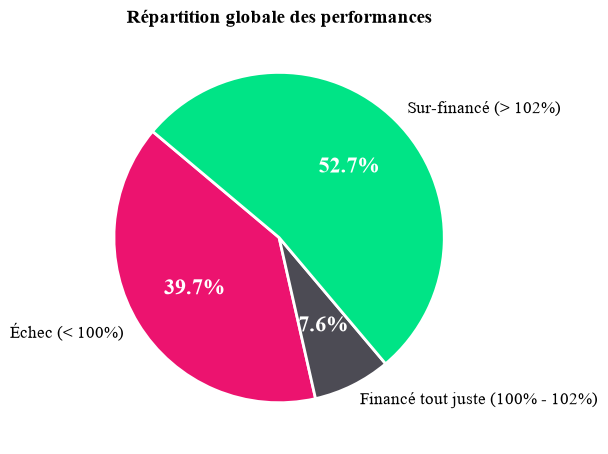

In [10]:
def categorize_funding(val):
    if val < 100:
        return "Échec (< 100%)"
    elif 100 <= val <= 102:
        return "Financé tout juste (100% - 102%)"
    else:
        return "Sur-financé (> 102%)"


df_completed['funding_category'] = df_completed['percent_funded'].apply(categorize_funding)
pie_data = df_completed['funding_category'].value_counts()


order = ["Échec (< 100%)", "Financé tout juste (100% - 102%)", "Sur-financé (> 102%)"]
pie_data = pie_data.reindex(order)


plt.figure(figsize=(6, 6))


custom_colors = ['#ec136f', '#4c4b54', "#00e486"]

wedges, texts, autotexts = plt.pie(
    pie_data, 
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140, 
    colors=custom_colors,
    wedgeprops=dict(edgecolor='#ffffff', linewidth=2) # Liseré blanc strict
)


plt.title("Répartition globale des performances")

plt.setp(autotexts, fontsize=16, fontweight='bold', color='#ffffff')

plt.tight_layout()
plt.show()

In [11]:
super_funded_df = kickstarter_df[kickstarter_df['performance_tier'] == 'Super-funded >1000%'].copy()

# Tri
super_funded_df = super_funded_df.sort_values(by='percent_funded', ascending=False)

colonnes_super_funded = [
    'name', 
    'main_category', 
    'goal_eur', 
    'pledged_eur', 
    'percent_funded'
]

print("--- TOP 15 DES PROJETS SUPER-FUNDED ---")
display(super_funded_df[colonnes_super_funded].head(15))

--- TOP 15 DES PROJETS SUPER-FUNDED ---


,name,main_category,goal_eur,pledged_eur,percent_funded
13821,AdventureQuest Worlds: Infinity,Games,0.88,1891475.52,214940400.0
60782,Laurent Garnier: Off the Record,Film & Video,1.11,172172.13,15532039.0
24013,Voyage - New Album Campaign by The Longest Johns,Music,1.12,154291.45,13806700.0
182696,Re-covering with Friends,Music,0.88,60512.41,6876410.0
171087,The Swapper3D: NO MORE PURGE BLOCKS!,Technology,0.68,37602.54,5500829.0
66668,LET ME HOLD A DOLLA! | LARUSSELL GOES MAJORLY ...,Music,0.88,34692.24,3942300.0
22994,Tim Rose Visual Album: <3,Film & Video,0.88,25245.60,2868818.0
48727,CLOCKWRIGHT: Large-Scale Analogue Time Machines,Art,0.88,24277.64,2758823.0
51342,"Penny Arcade's Podcast, ""Downloadable Content""...",Publishing,8.80,202717.39,2303606.7
88148,"Multi-Purpose, All-Occasion Greeting Cards",Crafts,1.76,22132.26,1257515.0


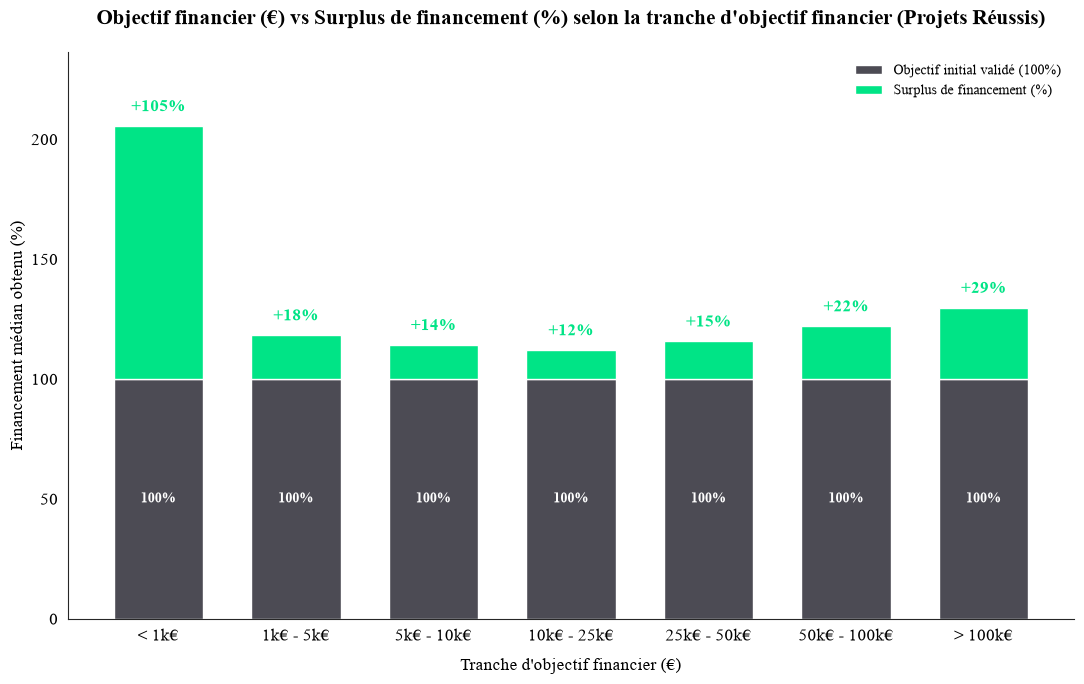

In [12]:
bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']
df_success['goal_bin'] = pd.cut(df_success['goal_eur'], bins=bins_goal, labels=labels_goal)

goal_perf = df_success.groupby('goal_bin', observed=True)['percent_funded'].median().reset_index()

goal_perf['base_100'] = 100
goal_perf['surplus_pct'] = goal_perf['percent_funded'] - 100

plt.figure(figsize=(11, 7))

plt.bar(
    goal_perf['goal_bin'], 
    goal_perf['base_100'], 
    color='#4c4b54', 
    label="Objectif initial validé (100%)",
    width=0.65
)

plt.bar(
    goal_perf['goal_bin'], 
    goal_perf['surplus_pct'], 
    bottom=goal_perf['base_100'],
    color='#00e486',
    label="Surplus de financement (%)",
    width=0.65
)

for i in range(len(goal_perf)):
    base = goal_perf['base_100'].iloc[i]
    surplus = goal_perf['surplus_pct'].iloc[i]
    total = goal_perf['percent_funded'].iloc[i]

    plt.annotate(
        "100%",
        (i, base / 2), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    if surplus > 0:
        plt.annotate(
            f"+{int(surplus)}%",
            (i, total),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color="#00e486"
        )


plt.title("Objectif financier (€) vs Surplus de financement (%) selon la tranche d'objectif financier (Projets Réussis)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Tranche d'objectif financier (€)", fontsize=12, labelpad=10)
plt.ylabel("Financement médian obtenu (%)", fontsize=12)

plt.ylim(0, goal_perf['percent_funded'].max() * 1.15)

sns.despine()
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

* Les projets fixant un objectif de moins de 1000 € sur-performent le plus. Fixer un objectif plancher très bas peut être une technique d'amorçage intéressante. Cela permet de valider le financement, de voir son projet en "Spotlight" et d'enclencher la preuve sociale.

* Sur les tranches intermédiaires, le taux de performance se stabilise entre 112 et 122%.

* Paradoxalement, les projets très ambitieux qui parviennent à réussir affichent une remontée de leur performance à 129%. Même si le taux de succès s'effondre sur ces gros montants, si un porteur de projet parvient à le réussir, cela constitue une forte preuve sociale.


### Analyse des fonds collectés
* Volume total récolté sur la plateforme et médiane des montants levés.

In [13]:
volume_total = kickstarter_df['pledged_eur'].sum()
mediane_globale = kickstarter_df['pledged_eur'].median()
moyenne_globale = kickstarter_df['pledged_eur'].mean()

volume_success = df_success['pledged_eur'].sum()
mediane_success = df_success['pledged_eur'].median()
moyenne_success = df_success['pledged_eur'].mean()

print(f"Volume total récolté sur la plateforme : {volume_total:,.0f} €")
print(f"Médiane globale des montants levés : {mediane_globale:,.0f} €")
print(f"Moyenne globale des montants levés : {moyenne_globale:,.0f} €")
print("------------------------------------------------")
print(f"Volume récolté (uniquement projets réussis) : {volume_success:,.0f} €")
print(f"Médiane des levées (uniquement projets réussis) : {mediane_success:,.0f} €")
print(f"Moyenne des levées (uniquement projets réussis) : {moyenne_success:,.0f} €")

Volume total récolté sur la plateforme : 2,947,266,707 €
Médiane globale des montants levés : 1,617 €
Moyenne globale des montants levés : 14,632 €
------------------------------------------------
Volume récolté (uniquement projets réussis) : 2,800,687,212 €
Médiane des levées (uniquement projets réussis) : 4,452 €
Moyenne des levées (uniquement projets réussis) : 23,418 €


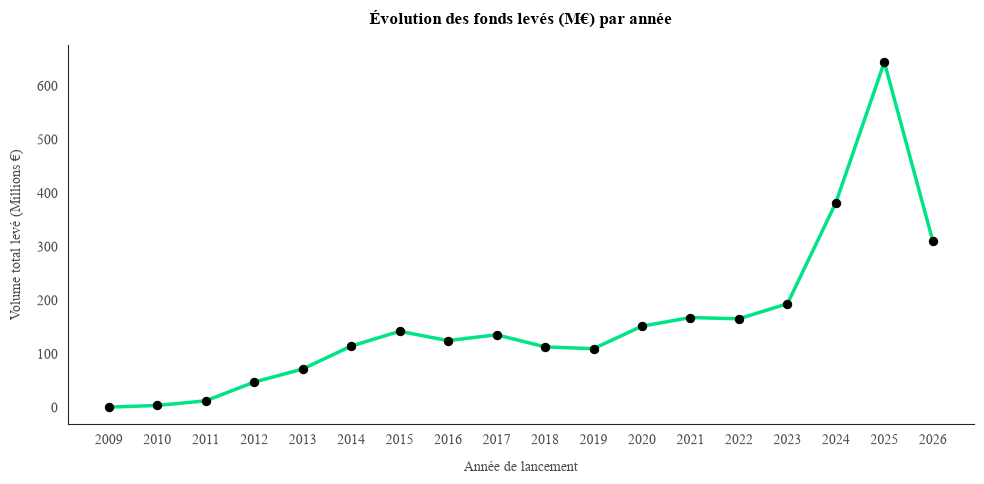

In [14]:

gmv_per_year = df_completed.groupby('launch_year')['pledged_eur'].sum().reset_index()

gmv_per_year['gmv_millions'] = gmv_per_year['pledged_eur'] / 1_000_000


plt.figure(figsize=(10, 5))

sns.lineplot(
    data=gmv_per_year, 
    x='launch_year', 
    y='gmv_millions', 
    color='#00e486', 
    linewidth=2.5, 
    marker='o',
    markersize=6,
    markerfacecolor='#000000', 
    markeredgecolor='#000000'
)

plt.title('Évolution des fonds levés (M€) par année', fontsize=12, fontweight='bold', color='#000000', pad=15)
plt.xlabel('Année de lancement', fontsize=10, color='#4c4b54', labelpad=10)
plt.ylabel('Volume total levé (Millions €)', fontsize=10, color='#4c4b54', labelpad=10)

plt.xticks(gmv_per_year['launch_year'], fontsize=10, color='#4c4b54') 
plt.yticks(fontsize=10, color='#4c4b54')

sns.despine()
plt.tight_layout()
plt.show()

On constate une grande différence entre médiane et moyenne, ce qui indique de très grandes disparités de levées de fonds. On va donc se concentrer sur la médiane qui se rapproche de la réalité du plus grand nombre de projets.

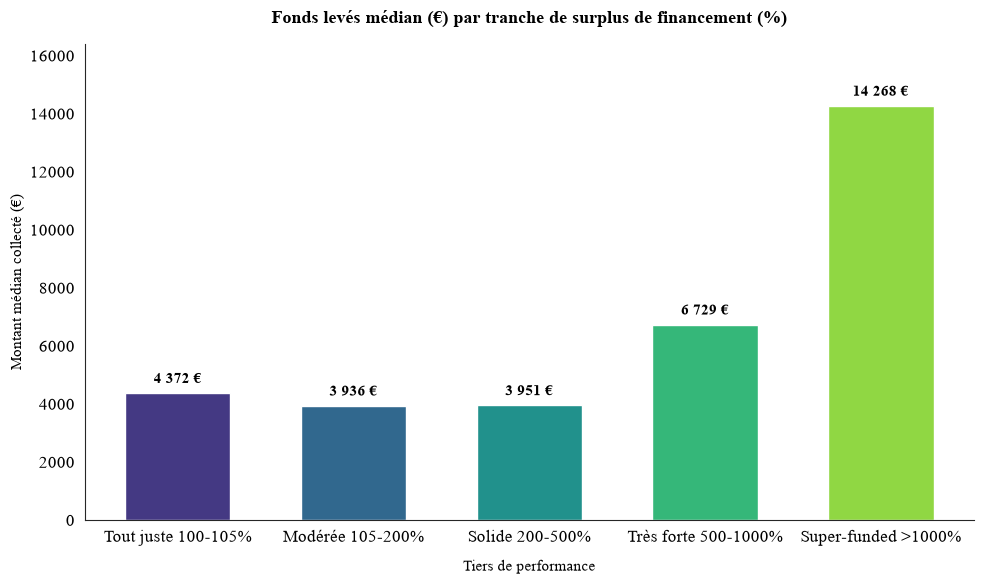

In [15]:
median_by_tier = kickstarter_df.groupby('performance_tier')['pledged_eur'].median().reindex(ordered_tiers)


plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(median_by_tier))

bars = plt.bar(median_by_tier.index, median_by_tier.values, color=colors, width=0.6)


plt.title("Fonds levés médian (€) par tranche de surplus de financement (%)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tiers de performance", fontsize=11, labelpad=10)
plt.ylabel("Montant médian collecté (€)", fontsize=11)

plt.ylim(0, median_by_tier.max() * 1.15)


for bar in bars:
    height = bar.get_height()
    if pd.notnull(height):
        plt.annotate(
            f'{height:,.0f} €'.replace(',', ' '), 
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5), 
            textcoords="offset points",
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

sns.despine()
plt.tight_layout()
plt.show()

## Temporalité

### Évolution annuelle
* Tendance de croissance du nombre de projets et du volume financier au fil des ans.
* Évolution du taux de succès au fil du temps.

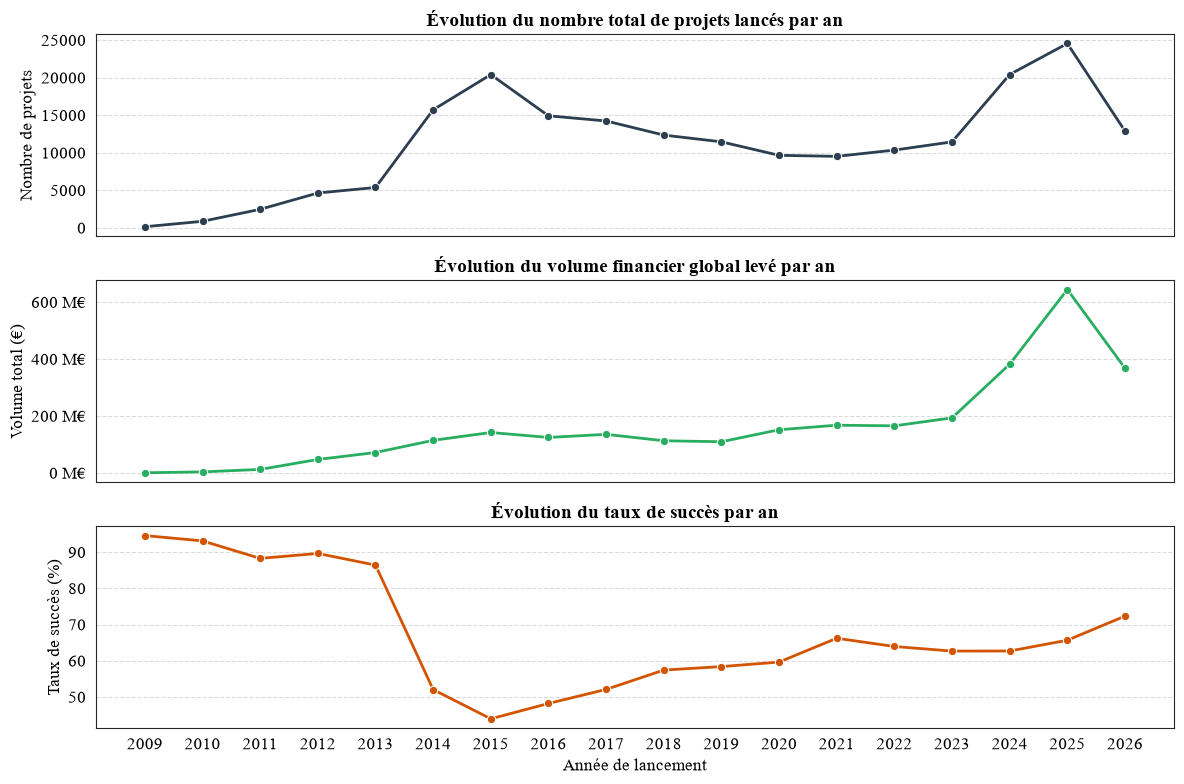

In [ ]:
yearly_global = kickstarter_df.groupby('launch_year').agg(
    num_projects=('name', 'count'),
    total_volume=('pledged_eur', 'sum')
).reset_index()

yearly_success = df_completed.groupby('launch_year').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

yearly_stats = pd.merge(yearly_global, yearly_success, on='launch_year', how='left')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=yearly_stats, x='launch_year', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par an", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.lineplot(data=yearly_stats, x='launch_year', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par an", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

sns.lineplot(data=yearly_stats, x='launch_year', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par an", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Année de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

axes[2].set_xticks(yearly_stats['launch_year'])

plt.tight_layout()
plt.show()

En regardant ces trois graphiques, on voit une correction assez nette du taux de réussite entre 2013 et 2015. Le marché de Kickstarter a gagné en maturité. Depuis 2023, le volume financier levé a connu une nette hausse qui semble corrélée à l'augmentation du nombre de projets lancés ; cela dit, le taux de succès reste plutôt stable, avec une tendance haussière assez timide depuis 2024.

L'année 2026 n'est pas encore terminée donc il est impossible d'en savoir plus, mais la tendance est haussière ce qui devrait encourager les entrepreneurs et les start-ups à tester leurs idées sur la plateforme.

### Saisonnalité
* Y a-t-il un "meilleur mois" pour lancer un projet (taux de succès + volume) ?

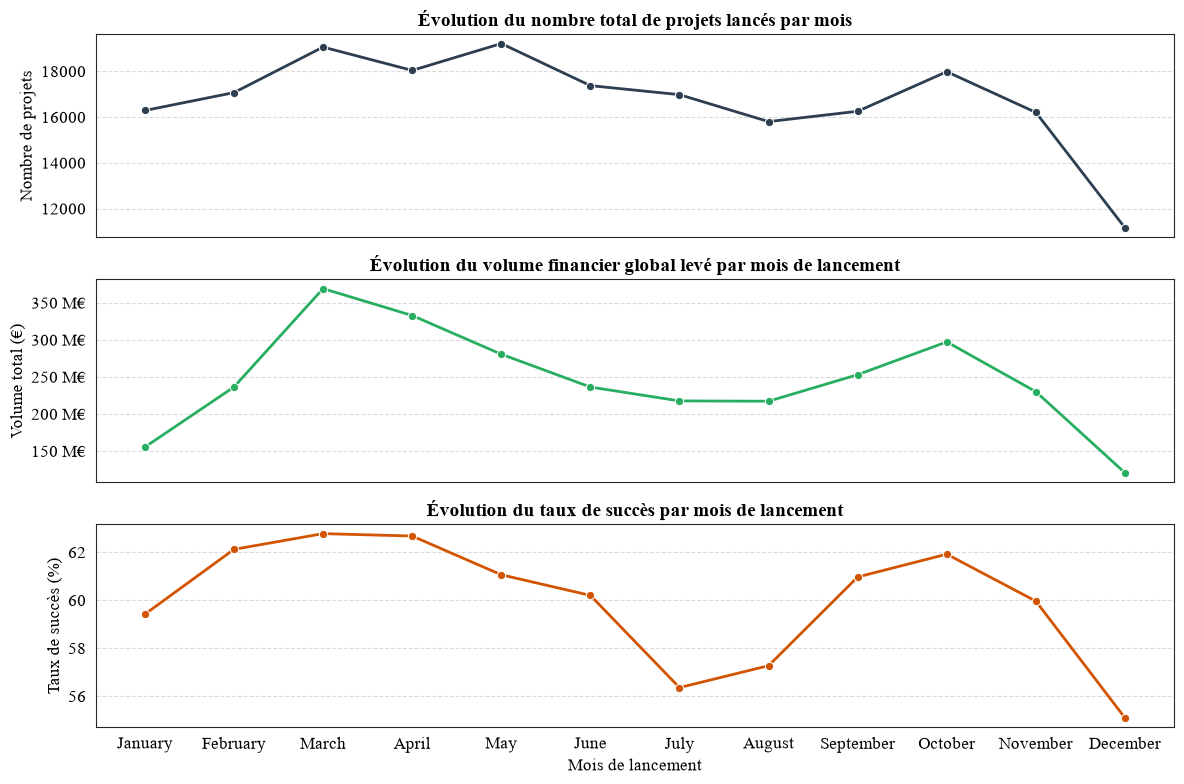

launch_month
January      16288
February     17070
March        19060
April        18039
May          19213
June         17375
July         16980
August       15803
September    16254
October      17983
November     16204
December     11162
Name: count, dtype: int64


In [ ]:
ordre_mois = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']

kickstarter_df['launch_month'] = pd.Categorical(kickstarter_df['launch_month'], categories=ordre_mois, ordered=True)

monthly_global = kickstarter_df.groupby('launch_month', observed=False).agg(
    num_projects=('name', 'count'),      
    total_volume=('pledged_eur', 'sum')  
).reset_index()

monthly_success = df_completed.groupby('launch_month', observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

monthly_stats = pd.merge(monthly_global, monthly_success, on='launch_month', how='left')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Nombre total de projets par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par mois", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Volume financier global par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par mois de lancement", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

# Graphique 3 : Taux de succès par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par mois de lancement", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Mois de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(kickstarter_df['launch_month'].value_counts().sort_index())

A priori, lancer sa campagne pendant les vacances de Noël (Décembre - Janvier) et pendant les vacances d'été (Juillet - Août) n'est pas recommandé car le taux de succès et le volume levé chute durant ces périodes. Il est important de noter que le nombre de projets lancés durant ces périodes chute également (sauf en Juillet) donc à prendre avec un grain de sel, mais si on ne souhaite vraiment pas prendre de risque, il vaut mieux éviter ces périodes.

### Durée de la campagne
* Est-ce que les campagnes plus courtes réussissent mieux que les campagnes longues ?

In [18]:
print("====== Statistiques de la durée des campagnes (en jours) ======")
print(kickstarter_df['duration_days'].describe())

====== Statistiques de la durée des campagnes (en jours) ======
count    201431.000000
mean         33.089490
std          12.886899
min           1.000000
25%          29.000000
50%          30.000000
75%          36.000000
max         120.000000
Name: duration_days, dtype: float64


/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/1648698115.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=success_rate_duration.index, y=success_rate_duration.values, palette='rainbow')


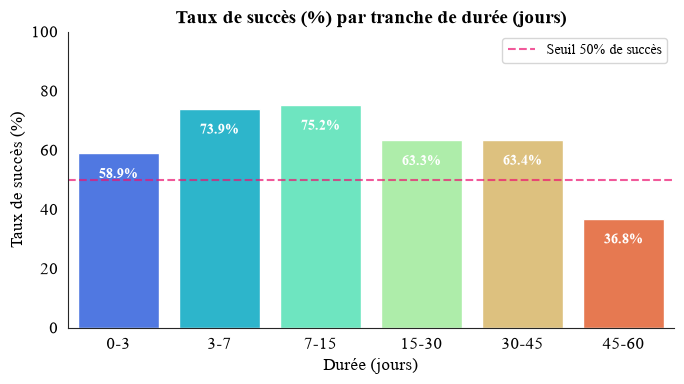

In [53]:
filtered_duration = df_completed[df_completed['duration_days'] <= 60].copy()


bins_duration = [0, 3, 7, 15, 30, 45, 60]
labels_duration = ['0-3', '3-7', '7-15', '15-30', '30-45', '45-60']

filtered_duration['duration_days'] = pd.cut(filtered_duration['duration_days'], bins=bins_duration, labels=labels_duration)

success_rate_duration = filtered_duration.groupby('duration_days', observed=False)['is_success'].mean() * 100


plt.figure(figsize=(7, 4))


bars = sns.barplot(x=success_rate_duration.index, y=success_rate_duration.values, palette='rainbow')


plt.title("Taux de succès (%) par tranche de durée (jours)")
plt.ylabel("Taux de succès (%)")
plt.xlabel("Durée (jours)")
plt.ylim(0, 100)


plt.axhline(
    50, color='#ec136f', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)


for bar in bars.patches:
    
    if bar.get_height() > 0:
        plt.annotate(
            f'{bar.get_height():.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, -20), 
            textcoords="offset points",
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color='white'
        )

sns.despine()

plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

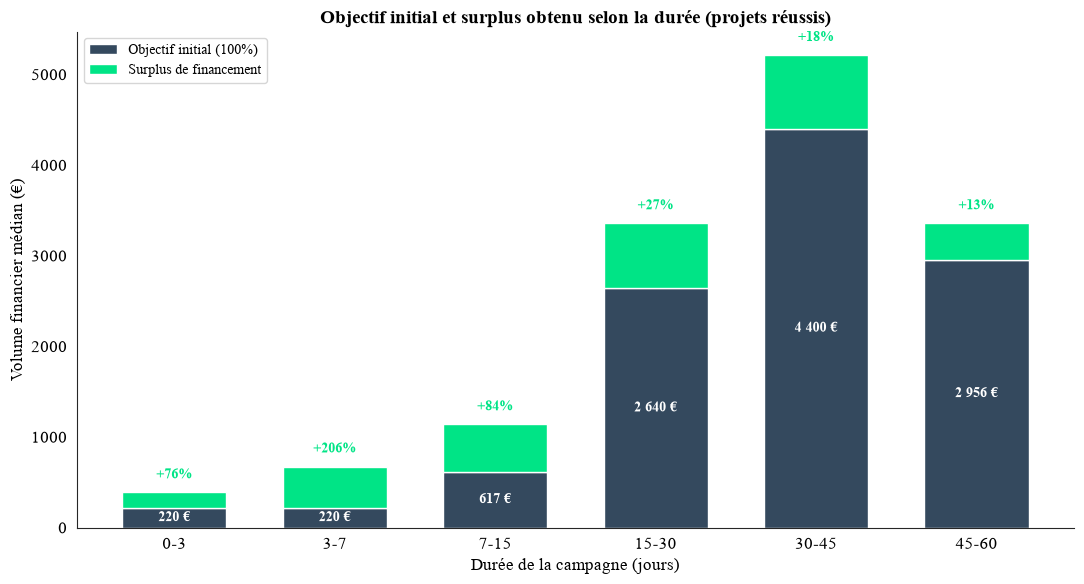

In [54]:
filtered_duration = df_completed[df_completed['duration_days'] <= 60].copy()

df_success = filtered_duration[filtered_duration['state'] == 'successful'].copy()

bins_duration = [0, 3, 7, 15, 30, 45, 60]
labels_duration = ['0-3', '3-7', '7-15', '15-30', '30-45', '45-60']

df_success['duration_category'] = pd.cut(df_success['duration_days'], bins=bins_duration, labels=labels_duration)

agg_success = df_success.groupby('duration_category', observed=False).agg(
    median_goal=('goal_eur', 'median'),
    median_funded=('percent_funded', 'median')
).reset_index()

agg_success['surplus_pct'] = agg_success['median_funded'] - 100
agg_success['surplus_eur'] = agg_success['median_goal'] * (agg_success['surplus_pct'] / 100)

plt.figure(figsize=(11, 6))

plt.bar(
    agg_success['duration_category'], 
    agg_success['median_goal'], 
    color='#34495e',
    label="Objectif initial (100%)",
    width=0.65
)

plt.bar(
    agg_success['duration_category'], 
    agg_success['surplus_eur'], 
    bottom=agg_success['median_goal'], 
    color='#00e486', 
    label="Surplus de financement",
    width=0.65
)

for i in range(len(agg_success)):
    goal = agg_success['median_goal'].iloc[i]
    surplus_eur = agg_success['surplus_eur'].iloc[i]
    surplus_pct = agg_success['surplus_pct'].iloc[i]
    total_height = goal + surplus_eur
    
    if pd.notnull(goal) and goal > 0:
        plt.annotate(
            f"{int(goal):,} €".replace(',', ' '),
            (i, goal / 2), 
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='white'
        )
        
        plt.annotate(
            f"+{int(surplus_pct)}%",
            (i, total_height),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#00e486'
        )

plt.title("Objectif initial et surplus obtenu selon la durée (projets réussis)")
plt.xlabel("Durée de la campagne (jours)")
plt.ylabel("Volume financier médian (€)")

sns.despine()
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Quelle durée recommandée pour chaque tranche d'objectif ?

--- RECOMMANDATION DE DURÉE PAR OBJECTIF FINANCIER ---
        goal_bin duration_bin  success_rate
2          < 1k€         7-15     84.600390
10     1k€ - 5k€        30-45     69.961710
16    5k€ - 10k€        30-45     65.467200
22   10k€ - 25k€        30-45     57.674200
28   25k€ - 50k€        30-45     46.221386
34  50k€ - 100k€        30-45     36.963190
40       > 100k€        30-45     19.193154


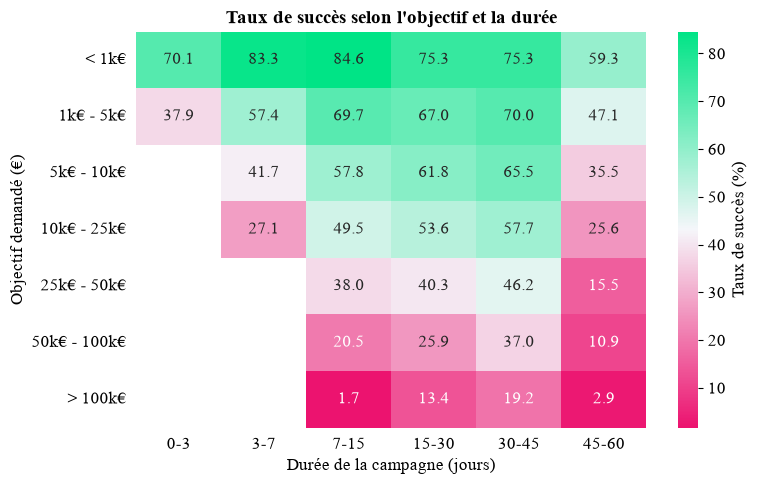

In [21]:
from matplotlib.colors import LinearSegmentedColormap

df_clean = df_completed[df_completed['duration_days'] <= 60].copy()

bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']
df_clean['goal_bin'] = pd.cut(df_clean['goal_eur'], bins=bins_goal, labels=labels_goal)

bins_duration = [0, 3, 7, 15, 30, 45, 60]
labels_duration = ['0-3', '3-7', '7-15', '15-30', '30-45', '45-60']
df_clean['duration_bin'] = pd.cut(df_clean['duration_days'], bins=bins_duration, labels=labels_duration)

matrix_stats = df_clean.groupby(['goal_bin', 'duration_bin'], observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

matrix_stats = matrix_stats[matrix_stats['volume'] >= 30]

optimal_duration = matrix_stats.sort_values(['goal_bin', 'success_rate'], ascending=[True, False])
optimal_duration = optimal_duration.groupby('goal_bin', observed=False).head(1)

print("--- RECOMMANDATION DE DURÉE PAR OBJECTIF FINANCIER ---")
print(optimal_duration[['goal_bin', 'duration_bin', 'success_rate']])

heatmap_data = matrix_stats.pivot(index='goal_bin', columns='duration_bin', values='success_rate')

plt.figure(figsize=(8, 5))

custom_cmap = LinearSegmentedColormap.from_list("custom_brand", ["#ec136f", "#f5f6fa", "#00e486"])

sns.heatmap(
    heatmap_data, 
    annot=True,          
    fmt=".1f",           
    cmap=custom_cmap,  # Application du dégradé personnalisé rouge -> vert
    cbar_kws={'label': 'Taux de succès (%)'}
)

plt.title("Taux de succès selon l'objectif et la durée")
plt.xlabel("Durée de la campagne (jours)")
plt.ylabel("Objectif demandé (€)")

plt.tight_layout()
plt.show()

### Phase de préparation
* Prendre du temps pour préparer sa page augmente-t-il les chances de succès ?

In [22]:
print("====== Statistiques de la durée de préparation (en jours) ======")
print(kickstarter_df['prep_days'].describe())

====== Statistiques de la durée de préparation (en jours) ======
count    201431.000000
mean         55.296404
std         161.537544
min           0.000000
25%           3.000000
50%          14.000000
75%          44.000000
max        5061.000000
Name: prep_days, dtype: float64


Ces statistiques ont mis en lumière la présence d'outliers. 5061 jours c'est 14 ans de préparation pour un projet. On peut considérer que ces outliers sont des comptes qui ont créé un brouillon de projet, l'ont abandonné et puis l'ont finalement lancé des années plus tard. Il ne s'agit donc pas d'un vrai temps de préparation.

Pour analyser au mieux, il faut créer des catégories de durée.

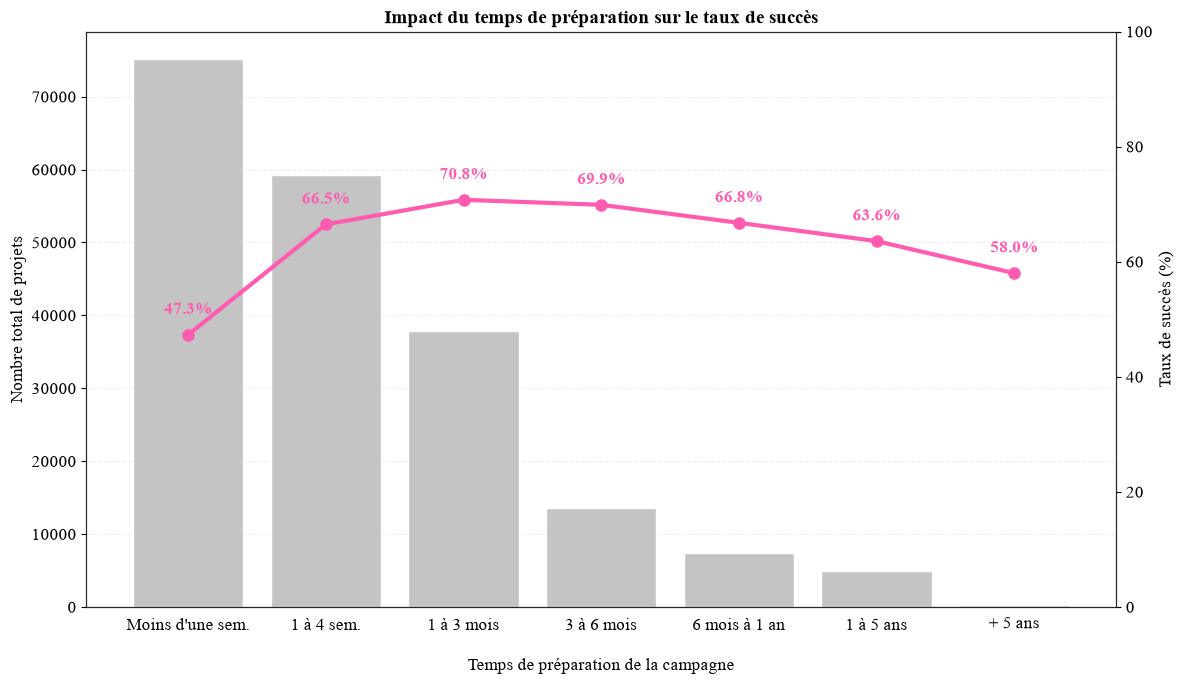

In [ ]:
bins = [-1, 7, 30, 90, 180, 365, 1825, float('inf')]
labels = [
    "Moins d'une sem.\n", 
    "1 à 4 sem.\n", 
    "1 à 3 mois\n", 
    "3 à 6 mois\n",
    "6 mois à 1 an\n",
    "1 à 5 ans\n", 
    "+ 5 ans"
]
df_completed['prep_tier'] = pd.cut(df_completed['prep_days'], bins=bins, labels=labels)

prep_stats = df_completed.groupby('prep_tier', observed=False).agg(
    num_projects=('is_success', 'count'),
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 7))

color_bar = "#c4c4c4"
bars = ax1.bar(prep_stats['prep_tier'], prep_stats['num_projects'], color=color_bar)
ax1.set_xlabel('Temps de préparation de la campagne')
ax1.set_ylabel('Nombre total de projets')
ax1.tick_params(axis='y')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
color_line = "#ff5bb0"
ax2.plot(prep_stats['prep_tier'], prep_stats['success_rate'], color=color_line, marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Taux de succès (%)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, 100)

for i, txt in enumerate(prep_stats['success_rate']):
    if not pd.isna(txt):
        ax2.annotate(f"{txt:.1f}%", 
                     (i, txt), 
                     textcoords="offset points", 
                     xytext=(0, 15), 
                     ha='center', 
                     color=color_line, 
                     fontweight='bold')

plt.title("Impact du temps de préparation sur le taux de succès")
plt.tight_layout()
plt.show()

En regardant ce graphique, on peut voir qu'il vaut mieux ne pas se précipiter pour lancer sa campagne. Les projets qui ont été préparés en moins d'une semaine ont moins d'une chance sur deux de réussir. Le pourcentage de chances de réussir augmente si la préparation prend entre 1 et 4 semaines, atteignant son sweet spot entre 1 et 3 mois. 

## Communauté

### Taille de communauté
* Combien de personnes soutiennent un projet en moyenne selon le statut ?

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/1106978468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/1106978468.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  barplot.set_xticklabels(['Succès', 'Échec', 'Annulé'])


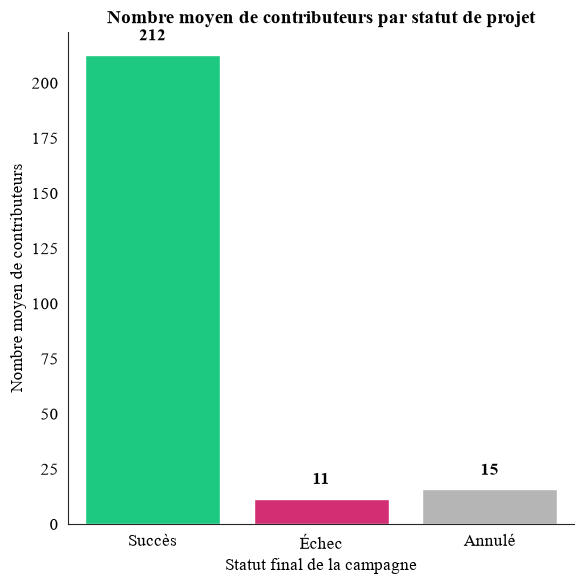

In [24]:

plt.figure(figsize=(6, 6))

barplot = sns.barplot(
    data=df_completed, 
    x='state', 
    y='backers_count', 
    order=['successful', 'failed', 'canceled'],
    palette=['#00e486', '#ec136f', "#b5b5b5"],
    errorbar=None
)

plt.title("Nombre moyen de contributeurs par statut de projet")
plt.xlabel("Statut final de la campagne")
plt.ylabel("Nombre moyen de contributeurs")

barplot.set_xticklabels(['Succès', 'Échec', 'Annulé'])

for p in barplot.patches:
    barplot.annotate(
        format(int(p.get_height()), ','),
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=12, fontweight='bold'
    )

sns.despine()

plt.tight_layout()
plt.show()

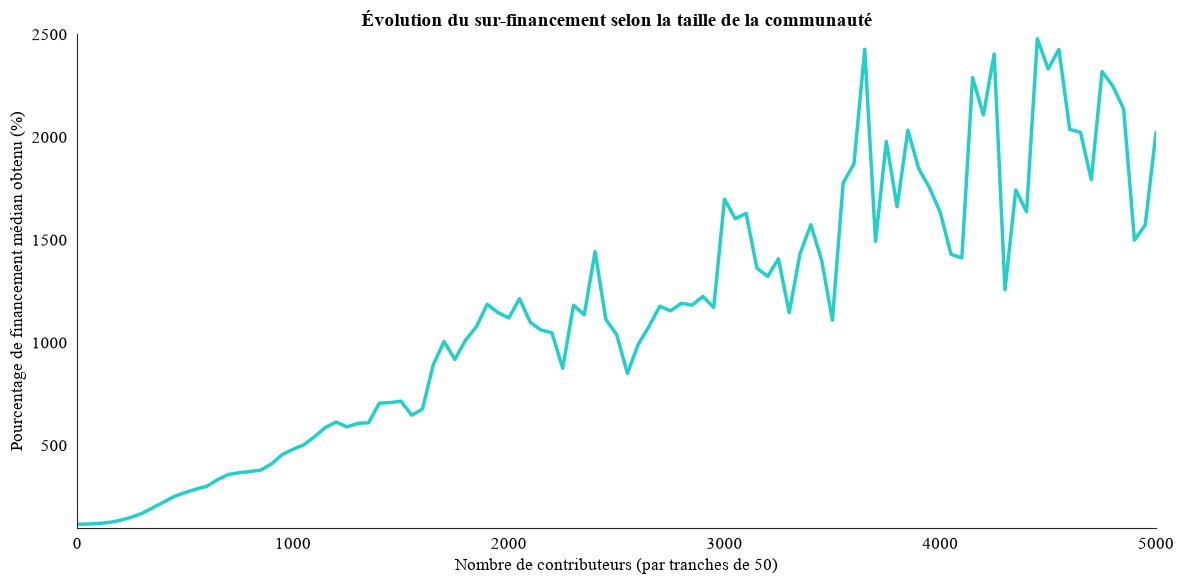

In [25]:
# Regrouper par tranches de 50 backers
df_success['backers_group'] = (df_success['backers_count'] // 50) * 50

trend_df = df_success.groupby('backers_group').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

trend_df = trend_df[trend_df['backers_group'] <= 5000]


trend_df['smoothed'] = trend_df['median_funded'].rolling(window=3, min_periods=1).mean()


plt.figure(figsize=(12, 6))

sns.lineplot(
    data=trend_df, 
    x='backers_group', 
    y='smoothed', 
    color="#24cfc7", 
    linewidth=2.5
)

plt.title("Évolution du sur-financement selon la taille de la communauté")
plt.xlabel("Nombre de contributeurs (par tranches de 50)")
plt.ylabel("Pourcentage de financement médian obtenu (%)")

plt.ylim(100, 2500)
plt.xlim(0, 5000)

sns.despine()
plt.tight_layout()
plt.show()

Le regroupement par paquet de 50 backers permet d'avoir une courbe de tendance plus lisible, car on calcule la médiane de performance par paquet de 50.

La courbe nous montre que la taille de la communauté est corrélée à la sur-performance d'un projet.

### Panier moyen
* Les projets financés s'appuient-ils sur beaucoup de petits donateurs ou sur quelques gros contributeurs ?

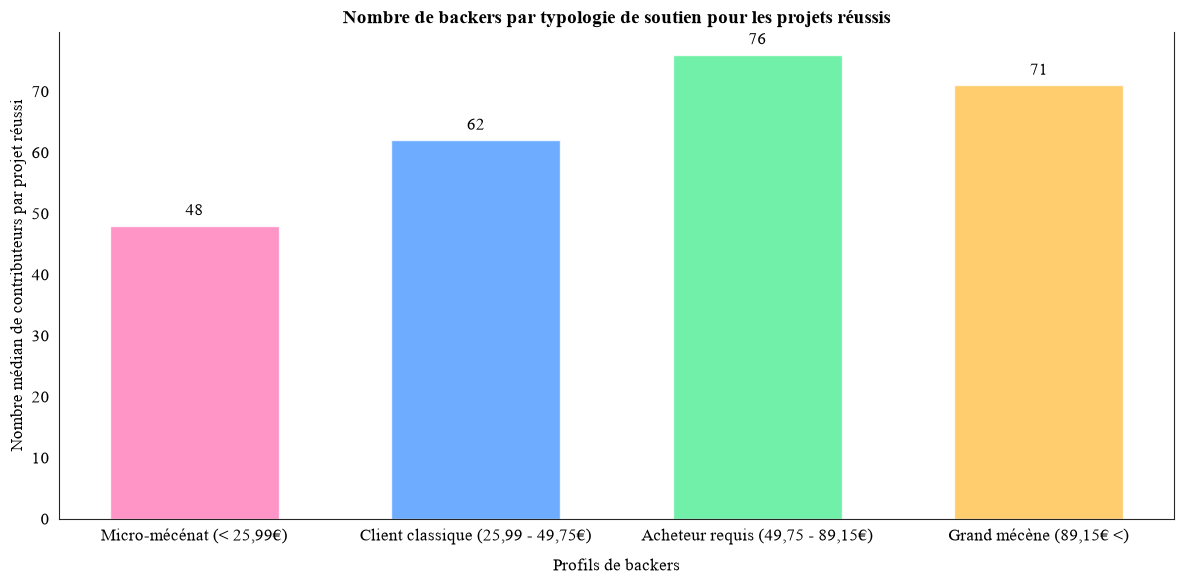

In [26]:
df_success = kickstarter_df[
    (kickstarter_df['state'] == 'successful') & 
    (kickstarter_df['backer_profile_qcut'] != 'Aucun soutien (0€)')
].copy()

stats_profile = df_success.groupby('backer_profile_qcut', observed=True).agg(
    median_backers=('backers_count', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

ordre_qcut = [
    'Micro-mécénat (< 25,99€)', 
    'Client classique (25,99 - 49,75€)', 
    'Acheteur requis (49,75 - 89,15€)', 
    'Grand mécène (89,15€ <)'
]
stats_profile['backer_profile_qcut'] = pd.Categorical(stats_profile['backer_profile_qcut'], categories=ordre_qcut, ordered=True)
stats_profile = stats_profile.sort_values('backer_profile_qcut')

fig, ax1 = plt.subplots(figsize=(12, 6))

color_backers =["#ff79ba", "#4998ff", "#4ced92", "#ffc04a"] 

bars = ax1.bar(stats_profile['backer_profile_qcut'], stats_profile['median_backers'], color=color_backers, alpha=0.8, width=0.6)
ax1.set_ylabel("Nombre médian de contributeurs par projet réussi")
ax1.tick_params(axis='y')
ax1.set_xlabel("Profils de backers", fontsize=12, labelpad=10)

for bar in bars.patches:
    ax1.annotate(f"{int(bar.get_height())}",
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', )

plt.title("Nombre de backers par typologie de soutien pour les projets réussis")
sns.despine(right=False)
plt.tight_layout()
plt.show()

In [27]:
valid_pledges = kickstarter_df[kickstarter_df['avg_basket_eur'] > 0]['avg_basket_eur']

# Seuils des quartiles du panier moyen
quartiles = valid_pledges.quantile([0, 0.25, 0.50, 0.75, 1.0])
print("Pour rappel, voici les seuils de panier moyen par type de backers :")
print(f"Min (0%)    : {quartiles[0.00]:.2f} €")
print(f"Q1  (25%)   : {quartiles[0.25]:.2f} €  -> Micro-mécénat")
print(f"Q2  (50%)   : {quartiles[0.50]:.2f} €  -> Client standard")
print(f"Q3  (75%)   : {quartiles[0.75]:.2f} €  -> Acheteur requis")
print(f"Max (100%)  : {quartiles[1.00]:.2f} €  -> Grand mécène")

Pour rappel, voici les seuils de panier moyen par type de backers :
Min (0%)    : 0.40 €
Q1  (25%)   : 25.99 €  -> Micro-mécénat
Q2  (50%)   : 49.75 €  -> Client standard
Q3  (75%)   : 89.15 €  -> Acheteur requis
Max (100%)  : 9651.02 €  -> Grand mécène


In [28]:
print("==== Médiane globale de backers nécessaires pour réussir ====")
print(df_success['backers_count'].median())

print("==== Moyenne globale de backers nécessaires pour réussir ====")
print(df_success['backers_count'].mean())

==== Médiane globale de backers nécessaires pour réussir ====
67.0
==== Moyenne globale de backers nécessaires pour réussir ====
212.6618030703368


Les projets qui se reposent sur des micro-mécènes n'ont pas les mêmes ambitions que les projets qui se reposent sur des grands mécènes.

* Pour réussir :
    * Si l'objectif est d'atteindre environ 300€, alors il y aura besoin de convertir environ 50 micro-mécènes.
    * Si l'objectif est d'atteindre environ 1320€, alors il y aura besoin de convertir environ 60 clients normaux.
    * Si l'objectif est d'atteindre environ 3 200€, alors il y aura besoin de convertir environ 75 acheteurs fans.
    * Si l'objectif est d'atteindre environ 7 000€, alors il y aura besoin de convertir environ 70 grands mécènes.

La médiane globale est à 67 contributeurs pour tous les projets qui réussissent.

### Typologie des soutiens
* Répartition et taux de succès selon le profil de contribution (Micro-mécénat, Acheteur requis, etc.).

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/1429074655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


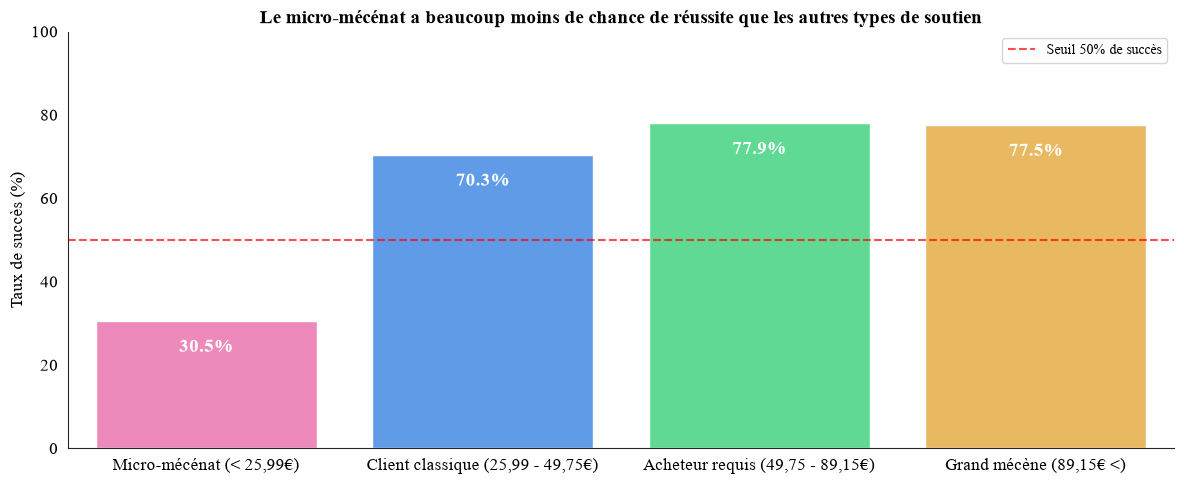

In [29]:
success_rate_backer_profile = df_completed.groupby('backer_profile_qcut', observed=False)['is_success'].mean() * 100
success_rate_backer_profile = success_rate_backer_profile.reindex(ordre_qcut)

plt.figure(figsize=(12, 5))

bars = sns.barplot(
    x=success_rate_backer_profile.index, 
    y=success_rate_backer_profile.values, 
    palette=["#ff79ba", "#4998ff", "#4ced92", "#ffc04a"] 
)

plt.title("Le micro-mécénat a beaucoup moins de chance de réussite que les autres types de soutien")
plt.ylabel("Taux de succès (%)")
plt.xlabel("") 
plt.ylim(0, 100)

plt.axhline(
    50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

for bar in bars.patches:
    height = bar.get_height()
    if pd.notnull(height) and height > 0: 
        plt.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, -25),
            textcoords="offset points",
            ha='center', va='bottom',
            color='white', fontweight='bold', fontsize='14'
        )


plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

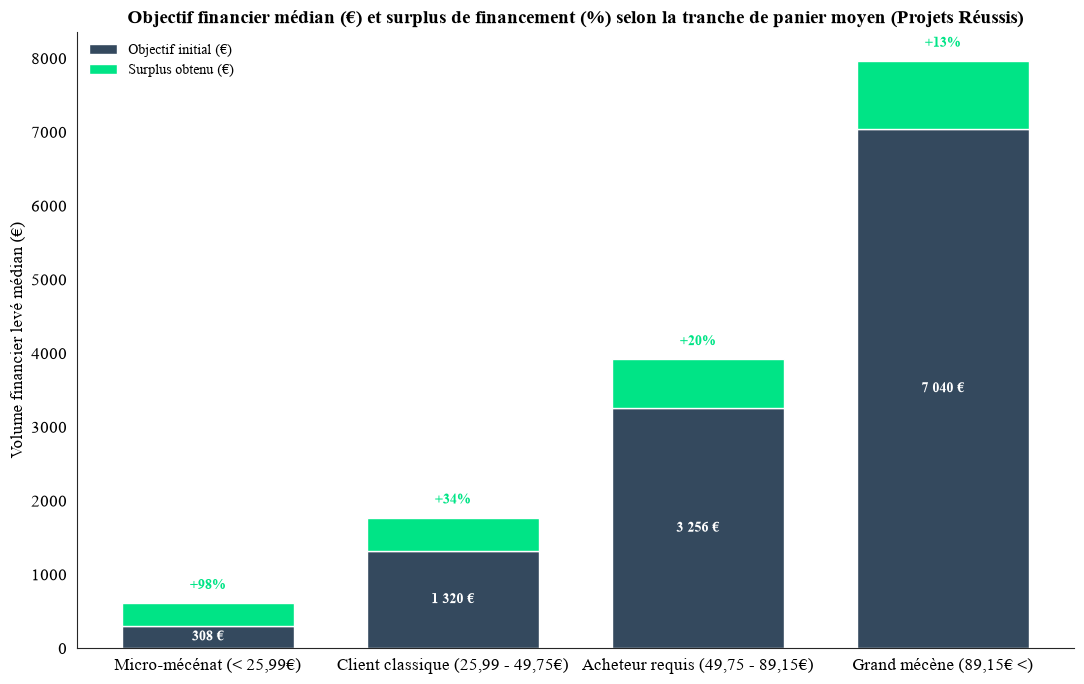

In [30]:
basket_perf = df_success.groupby('backer_profile_qcut', observed=True).agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

basket_perf = basket_perf[basket_perf['backer_profile_qcut'].isin(ordre_qcut)]
basket_perf['backer_profile_qcut'] = pd.Categorical(basket_perf['backer_profile_qcut'], categories=ordre_qcut, ordered=True)
basket_perf = basket_perf.sort_values('backer_profile_qcut')

basket_perf['surplus_pct'] = basket_perf['median_funded'] - 100

basket_perf['surplus_eur'] = basket_perf['median_goal'] * (basket_perf['surplus_pct'] / 100)

plt.figure(figsize=(11, 7))

plt.bar(
    basket_perf['backer_profile_qcut'], 
    basket_perf['median_goal'], 
    color='#34495e', 
    label="Objectif initial (€)",
    width=0.7
)

plt.bar(
    basket_perf['backer_profile_qcut'], 
    basket_perf['surplus_eur'], 
    bottom=basket_perf['median_goal'], 
    color='#00e486',
    label="Surplus obtenu (€)",
    width=0.7
)

for i in range(len(basket_perf)):
    goal = basket_perf['median_goal'].iloc[i]
    surplus_eur = basket_perf['surplus_eur'].iloc[i]
    surplus_pct = basket_perf['surplus_pct'].iloc[i]
    total_eur = goal + surplus_eur
    
    plt.annotate(
        f"{int(goal):,} €".replace(',', ' '), 
        (i, goal / 2), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    if surplus_pct > 0:
        plt.annotate(
            f"+{int(surplus_pct)}%",
            (i, total_eur),
            xytext=(0, 8), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#00e486' # Vert aligné
        )

plt.title("Objectif financier médian (€) et surplus de financement (%) selon la tranche de panier moyen (Projets Réussis)")
plt.xlabel("")
plt.ylabel("Volume financier levé médian (€)")

sns.despine()
plt.legend(loc='upper left', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

Les projets qui se reposent sur des micro-mécènes pour réussir ont des objectifs moins élevés et ont besoin de moins de contributeurs, mais leur chance de réussite est limitée comparée aux autres types de soutien. Il est donc capital pour les entrepreneurs d'attirer des profils plus qualitatifs et plus engagés pour maximiser leur chance de réussite.

En revanche lorsqu'on s'attarde sur la performance des projets réussis, les projets dont le type de soutien est micro-mécène performe 2 fois plus que ceux qui ont des grands mécènes.

--- RECOMMANDATION DE CIBLAGE PAR OBJECTIF FINANCIER ---
        goal_bin               backer_profile_qcut  success_rate
2          < 1k€  Acheteur requis (49,75 - 89,15€)     93.482437
7      1k€ - 5k€           Grand mécène (89,15€ <)     87.618343
11    5k€ - 10k€           Grand mécène (89,15€ <)     82.804628
15   10k€ - 25k€           Grand mécène (89,15€ <)     74.782290
19   25k€ - 50k€           Grand mécène (89,15€ <)     61.011298
23  50k€ - 100k€           Grand mécène (89,15€ <)     47.637604
27       > 100k€           Grand mécène (89,15€ <)     25.661376


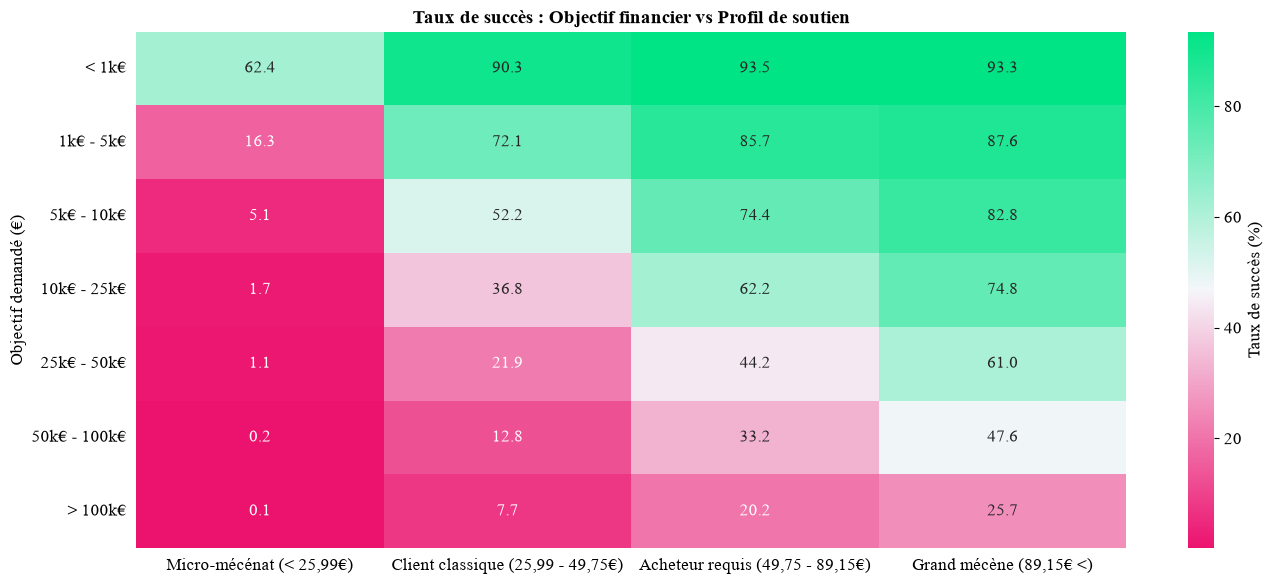

In [31]:
bins_goal = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels_goal = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']
df_clean['goal_bin'] = pd.cut(df_clean['goal_eur'], bins=bins_goal, labels=labels_goal)

df_filtered = df_clean[df_clean['backer_profile_qcut'] != 'Aucun soutien (0€)'].copy()

if hasattr(df_filtered['backer_profile_qcut'], 'cat'):
    df_filtered['backer_profile_qcut'] = df_filtered['backer_profile_qcut'].cat.remove_unused_categories()

df_filtered['backer_profile_qcut'] = pd.Categorical(
    df_filtered['backer_profile_qcut'], 
    categories=ordre_qcut, 
    ordered=True
)

matrix_persona = df_filtered.groupby(['goal_bin', 'backer_profile_qcut'], observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

matrix_persona = matrix_persona[matrix_persona['volume'] >= 30]

optimal_persona = matrix_persona.sort_values(['goal_bin', 'success_rate'], ascending=[True, False])
optimal_persona = optimal_persona.groupby('goal_bin', observed=False).head(1)

print("--- RECOMMANDATION DE CIBLAGE PAR OBJECTIF FINANCIER ---")
print(optimal_persona[['goal_bin', 'backer_profile_qcut', 'success_rate']])

heatmap_persona = matrix_persona.pivot(index='goal_bin', columns='backer_profile_qcut', values='success_rate')

plt.figure(figsize=(14, 6))

custom_cmap = LinearSegmentedColormap.from_list("custom_brand", ["#ec136f", "#f5f6fa", "#00e486"])

sns.heatmap(
    heatmap_persona, 
    annot=True,          
    fmt=".1f",           
    cmap=custom_cmap,
    cbar_kws={'label': 'Taux de succès (%)'}
)

plt.title("Taux de succès : Objectif financier vs Profil de soutien")
plt.xlabel("")
plt.ylabel("Objectif demandé (€)")

plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

## Catégories de projets

### Distribution par secteur

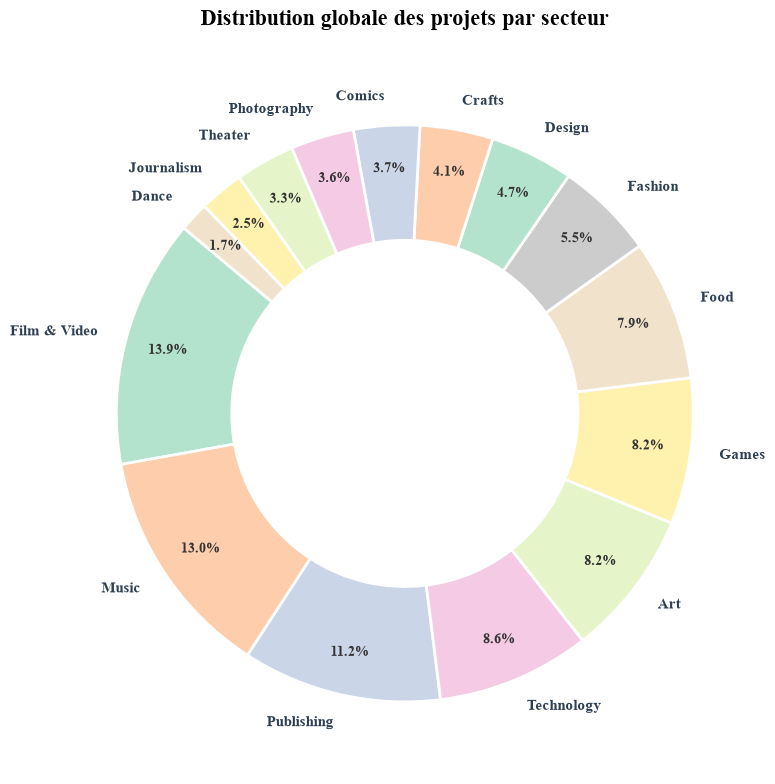

In [32]:
sector_counts = kickstarter_df['main_category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 8))

colors = sns.color_palette('Pastel2')[0:len(sector_counts)]

wedges, texts, autotexts = ax.pie(
    sector_counts, 
    labels=sector_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) # Le 'width' évide le centre
)

plt.setp(texts, fontsize=11, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=10, fontweight='bold', color='#333333')

plt.title("Distribution globale des projets par secteur", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

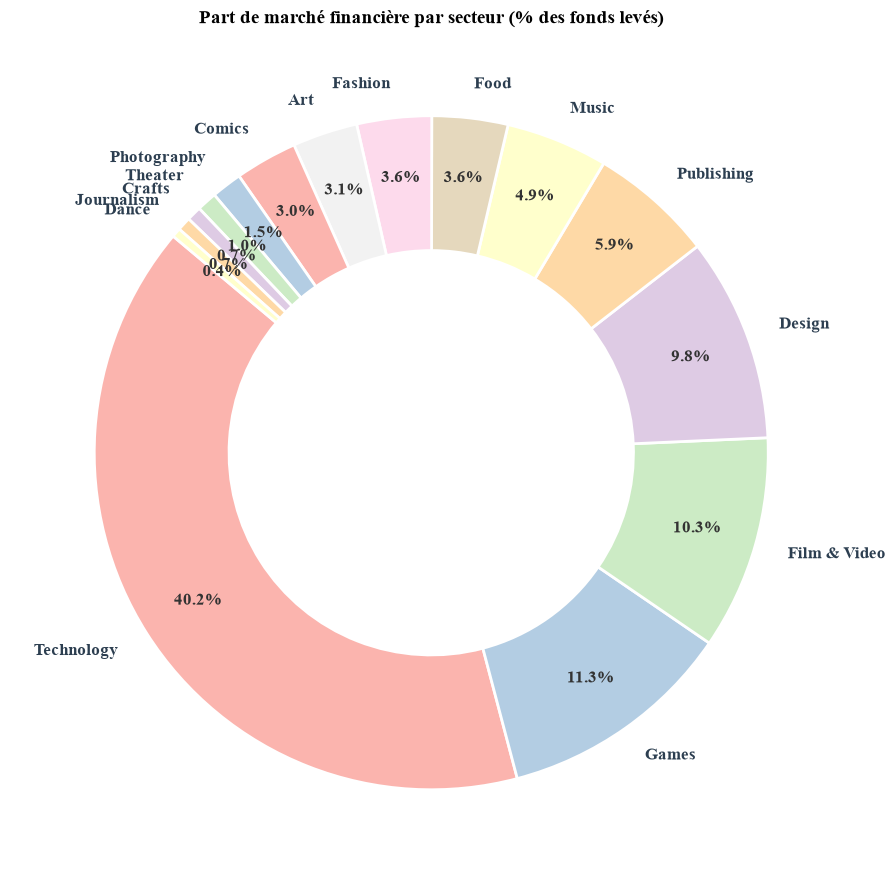

In [33]:
sector_pledged = kickstarter_df.groupby('main_category')['pledged_eur'].sum().sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 9))

colors = sns.color_palette('Pastel1')[0:len(sector_pledged)]

wedges, texts, autotexts = ax.pie(
    sector_pledged,
    labels=sector_pledged.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

plt.setp(texts, fontsize=12, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=12, fontweight='bold', color='#333333')

plt.title("Part de marché financière par secteur (% des fonds levés)")

plt.tight_layout()
plt.show()

### Performance par catégorie principale
* Top & Flop des catégories en termes de taux de succès et de fonds levés.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/3027474199.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_success, x='success_rate', y='main_category', palette='viridis', ax=ax1)
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/3027474199.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_funds, x='total_pledged', y='main_category', palette='rocket', ax=ax2)


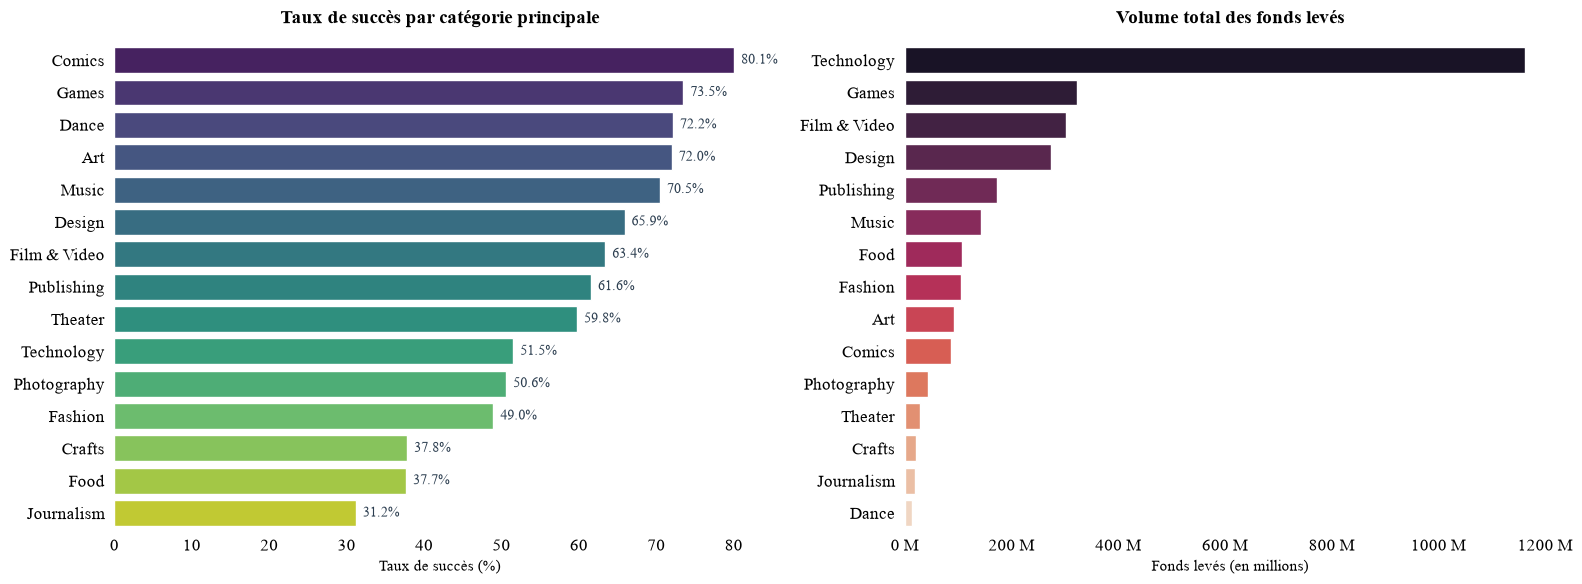

In [ ]:
cat_stats = df_completed.groupby('main_category').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    total_pledged=('pledged_eur', 'sum')
).reset_index()

cat_success = cat_stats.sort_values('success_rate', ascending=False)
cat_funds = cat_stats.sort_values('total_pledged', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=cat_success, x='success_rate', y='main_category', palette='viridis', ax=ax1)
ax1.set_title('Taux de succès par catégorie principale', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Taux de succès (%)', fontsize=11)
ax1.set_ylabel('')

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, color='#2c3e50')

sns.barplot(data=cat_funds, x='total_pledged', y='main_category', palette='rocket', ax=ax2)
ax2.set_title('Volume total des fonds levés', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fonds levés (en millions)', fontsize=11)
ax2.set_ylabel('') 

ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x*1e-6:.0f} M"))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

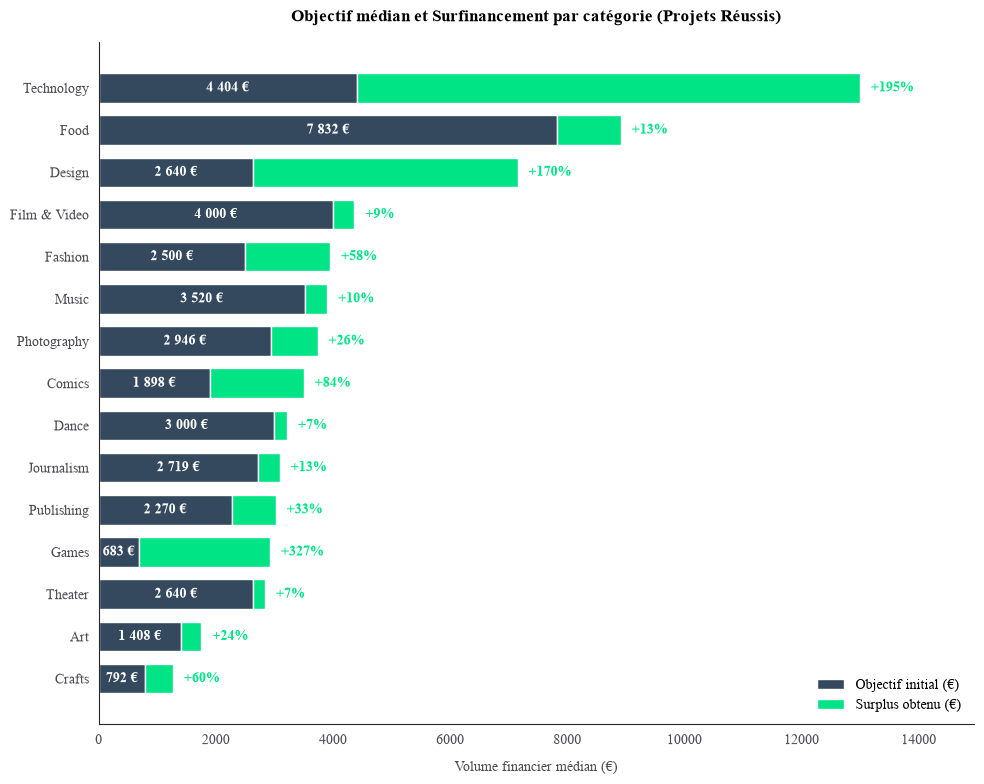

In [35]:
perf_cat_stats = df_success.groupby('main_category').agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

perf_cat_stats['surplus_pct'] = perf_cat_stats['median_funded'] - 100
perf_cat_stats['surplus_eur'] = perf_cat_stats['median_goal'] * (perf_cat_stats['surplus_pct'] / 100)
perf_cat_stats['total_eur'] = perf_cat_stats['median_goal'] + perf_cat_stats['surplus_eur']

perf_cat_stats = perf_cat_stats.sort_values('total_eur', ascending=True)

plt.figure(figsize=(10, 8)) 

y_positions = range(len(perf_cat_stats))
categories = perf_cat_stats['main_category']

plt.barh(
    y_positions, 
    perf_cat_stats['median_goal'], 
    color='#34495e', 
    label="Objectif initial (€)",
    height=0.7
)

plt.barh(
    y_positions, 
    perf_cat_stats['surplus_eur'], 
    left=perf_cat_stats['median_goal'],
    color='#00e486',
    label="Surplus obtenu (€)",
    height=0.7
)

for i in range(len(perf_cat_stats)):
    goal = perf_cat_stats['median_goal'].iloc[i]
    surplus_pct = perf_cat_stats['surplus_pct'].iloc[i]
    total_eur = perf_cat_stats['total_eur'].iloc[i]
    
   
    plt.annotate(
        f"{int(goal):,} €".replace(',', ' '), 
        (goal / 2, i), 
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )
    
    
    if surplus_pct > 0:
        plt.annotate(
            f"+{int(surplus_pct)}%",
            (total_eur, i),
            xytext=(8, 0), textcoords='offset points', 
            ha='left', va='center',
            fontsize=10, fontweight='bold', color='#00e486' # Vert aligné
        )

plt.yticks(y_positions, categories, fontsize=10, color='#4c4b54')
plt.title("Objectif médian et Surfinancement par catégorie (Projets Réussis)", fontsize=12, fontweight='bold', color='#000000', pad=15)
plt.xlabel("Volume financier médian (€)", fontsize=10, color='#4c4b54', labelpad=10)
plt.ylabel("")

plt.xticks(fontsize=10, color='#4c4b54')
plt.xlim(0, perf_cat_stats['total_eur'].max() * 1.15)

sns.despine()
plt.legend(loc='lower right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

Les secteurs qui sur-performent le plus sur les projets réussis sont les jeux, la technologie et le design.

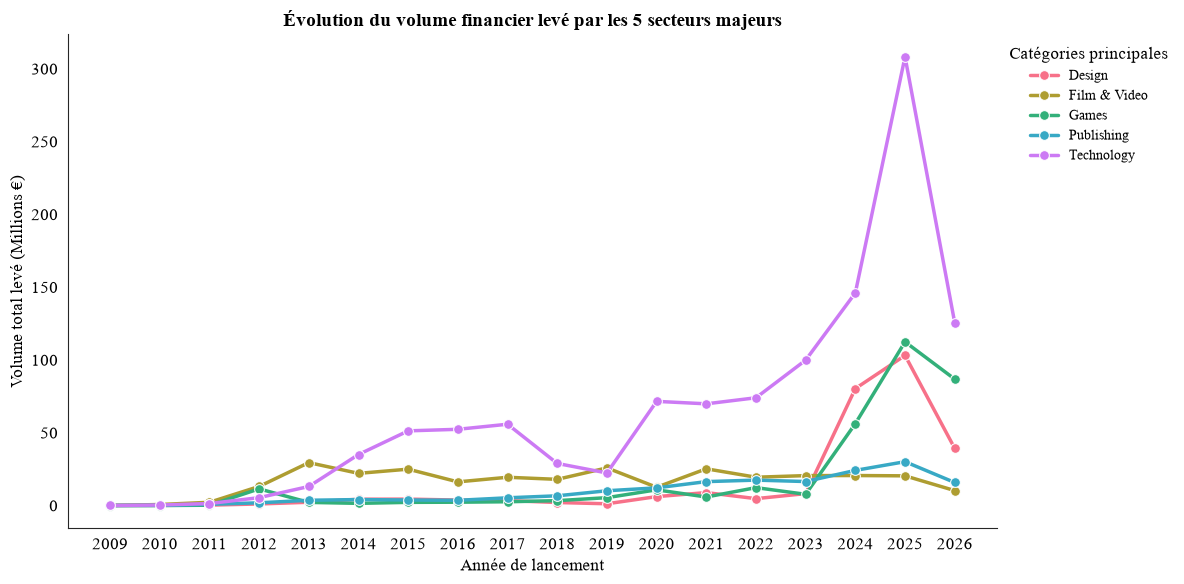

In [ ]:
top_categories = df_completed.groupby('main_category', observed=False)['pledged_eur'].sum().nlargest(5).index

df_top_cats = df_completed[df_completed['main_category'].isin(top_categories)].copy()

evolution_cat = df_top_cats.groupby(['launch_year', 'main_category'], observed=False)['pledged_eur'].sum().reset_index()

evolution_cat['pledged_millions'] = evolution_cat['pledged_eur'] / 1_000_000

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolution_cat, 
    x='launch_year', 
    y='pledged_millions', 
    hue='main_category',
    linewidth=2.5,
    marker='o',
    markersize=7,
    palette='husl'
)

plt.title("Évolution du volume financier levé par les 5 secteurs majeurs")
plt.xlabel("Année de lancement")
plt.ylabel("Volume total levé (Millions €)")

annees_uniques = evolution_cat['launch_year'].unique()
plt.xticks(annees_uniques)
plt.yticks()

sns.despine()

plt.legend(title="Catégories principales", loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

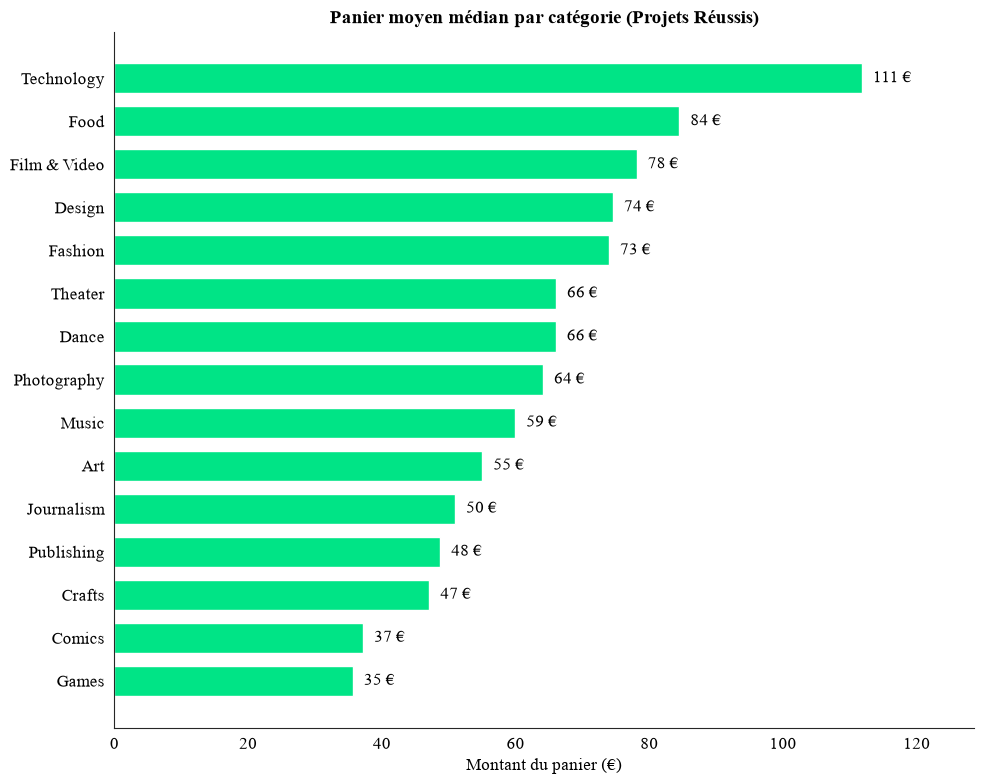

In [ ]:
basket_cat = df_success.groupby('main_category', observed=False).agg(
    median_basket=('avg_basket_eur', 'median')
).reset_index()

basket_cat = basket_cat.sort_values('median_basket', ascending=True)

plt.figure(figsize=(10, 8))

y_positions = range(len(basket_cat))
categories = basket_cat['main_category']

bars = plt.barh(
    y_positions, 
    basket_cat['median_basket'], 
    color='#00e486', 
    height=0.7
)

for bar in bars:
    width = bar.get_width()
    plt.annotate(
        f"{int(width)} €",
        (width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),
        textcoords="offset points",
        ha='left', va='center',
    )

plt.yticks(y_positions, categories)
plt.title("Panier moyen médian par catégorie (Projets Réussis)")
plt.xlabel("Montant du panier (€)")
plt.ylabel("")

plt.xlim(0, basket_cat['median_basket'].max() * 1.15)
plt.xticks()

sns.despine()
plt.tight_layout()
plt.show()

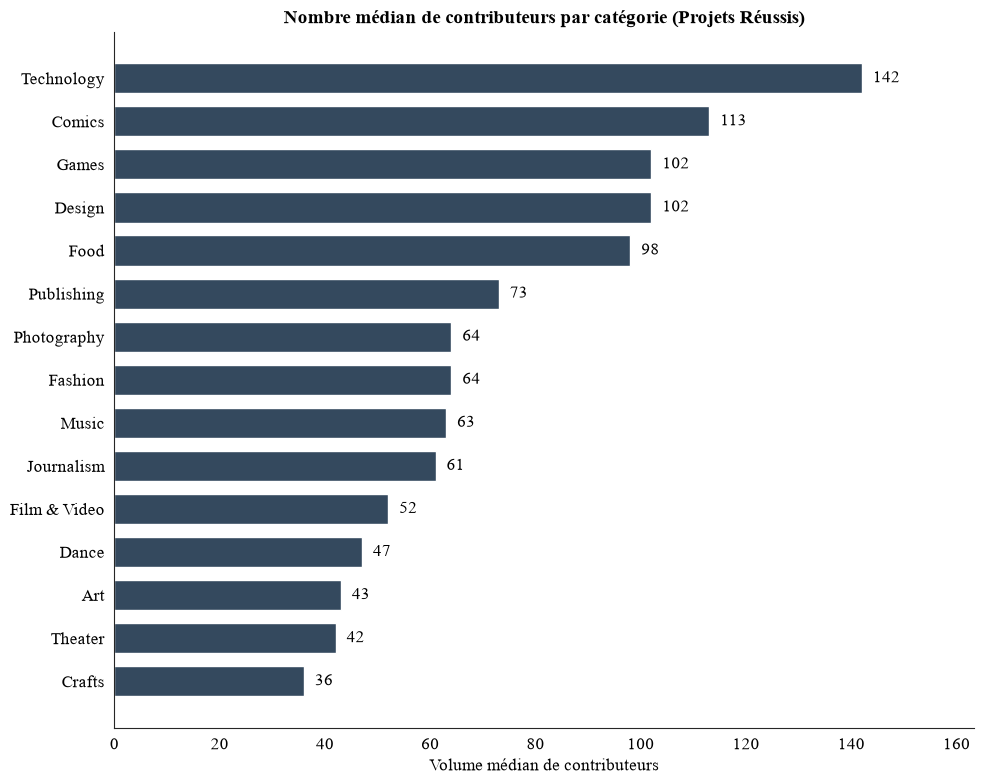

In [ ]:
backers_cat = df_success.groupby('main_category', observed=False).agg(
    median_backers=('backers_count', 'median')
).reset_index()

backers_cat = backers_cat.sort_values('median_backers', ascending=True)

plt.figure(figsize=(10, 8))

y_positions = range(len(backers_cat))
categories = backers_cat['main_category']

bars = plt.barh(
    y_positions, 
    backers_cat['median_backers'], 
    color='#34495e', 
    height=0.7
)

for bar in bars:
    width = bar.get_width()
    plt.annotate(
        f"{int(width)}",
        (width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0), 
        textcoords="offset points",
        ha='left', va='center',
    )

plt.yticks(y_positions, categories)
plt.title("Nombre médian de contributeurs par catégorie (Projets Réussis)")
plt.xlabel("Volume médian de contributeurs")
plt.ylabel("")

plt.xlim(0, backers_cat['median_backers'].max() * 1.15)
plt.xticks()

sns.despine()
plt.tight_layout()
plt.show()

### Focus sous-catégorie
On a vu avec le test de corrélation que la sous-catégorie a une influence plus forte sur l'issue de la campagne.
* Les sous-catégories à fort potentiel (celles qui dépassent largement leur médiane sectorielle cat_median_pledged_eur).

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/1498373340.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


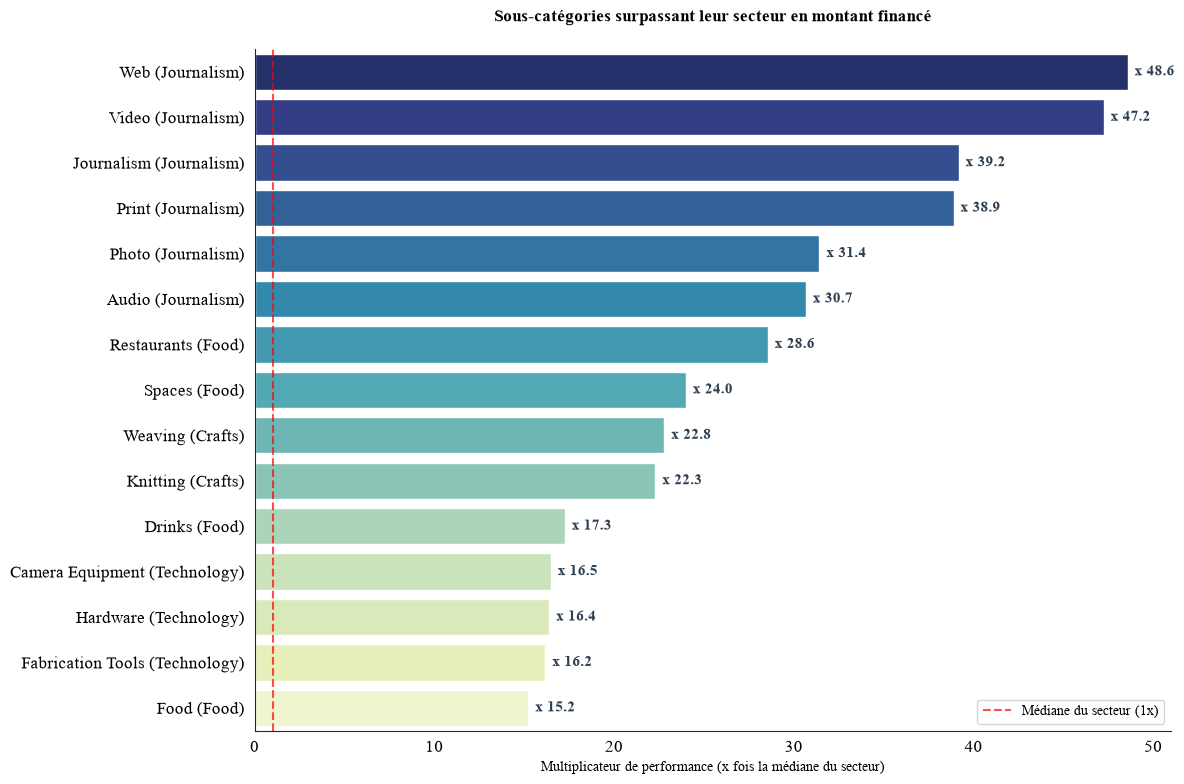

In [ ]:
subcat_stats = df_success.groupby(['main_category', 'sub_category', 'cat_median_pledged_eur']).agg(
    sub_median=('pledged_eur', 'median'),
).reset_index()

df_perf = pd.merge(subcat_stats, cat_stats, on='main_category')

df_perf['perf_multiplier'] = df_perf['sub_median'] / df_perf['cat_median_pledged_eur']

top_subcats = df_perf.sort_values('perf_multiplier', ascending=False).head(15)

top_subcats['label'] = top_subcats['sub_category'] + ' (' + top_subcats['main_category'] + ')'

plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=top_subcats, 
    x='perf_multiplier', 
    y='label', 
    palette='YlGnBu_r' 
)

plt.title("Sous-catégories surpassant leur secteur en montant financé", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Multiplicateur de performance (x fois la médiane du secteur)", fontsize=10)
plt.ylabel("")

plt.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Médiane du secteur (1x)')
plt.legend(loc='lower right')

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"x {width:.1f}",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

### Objectif VS réalité par secteur
* Quelles catégories demandent les objectifs financiers les plus réalistes/élevés ?

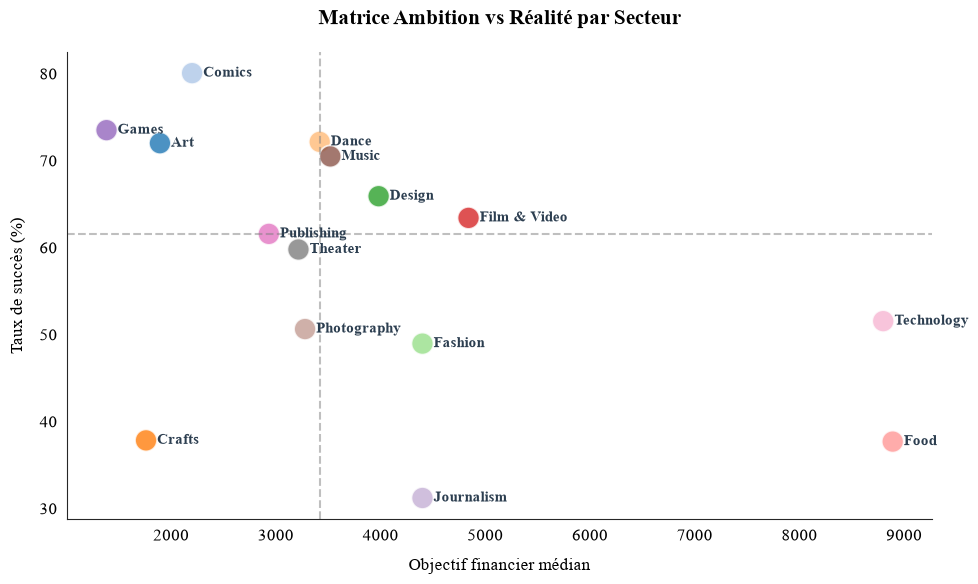

In [ ]:
sector_stats = df_completed.groupby('main_category', observed=False).agg(
    median_goal=('goal_eur', 'median'), # L'objectif (Ambition)
    success_rate=('is_success', lambda x: x.mean() * 100) # La réalité (Réalisme)
).reset_index()

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=sector_stats,
    x='median_goal',
    y='success_rate',
    hue='main_category',
    s=250, 
    palette='tab20',
    legend=False,
    alpha=0.8
)

for i in range(sector_stats.shape[0]):
    plt.annotate(
        sector_stats['main_category'].iloc[i],
        (sector_stats['median_goal'].iloc[i], sector_stats['success_rate'].iloc[i]),
        xytext=(8, 0), textcoords='offset points', 
        ha='left', va='center',
        fontsize=11, fontweight='bold', color='#2c3e50'
    )

plt.axvline(x=sector_stats['median_goal'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=sector_stats['success_rate'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title("Matrice Ambition vs Réalité par Secteur", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Objectif financier médian", fontsize=12, labelpad=10)
plt.ylabel("Taux de succès (%)", fontsize=12, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

### Meilleures niches par secteur

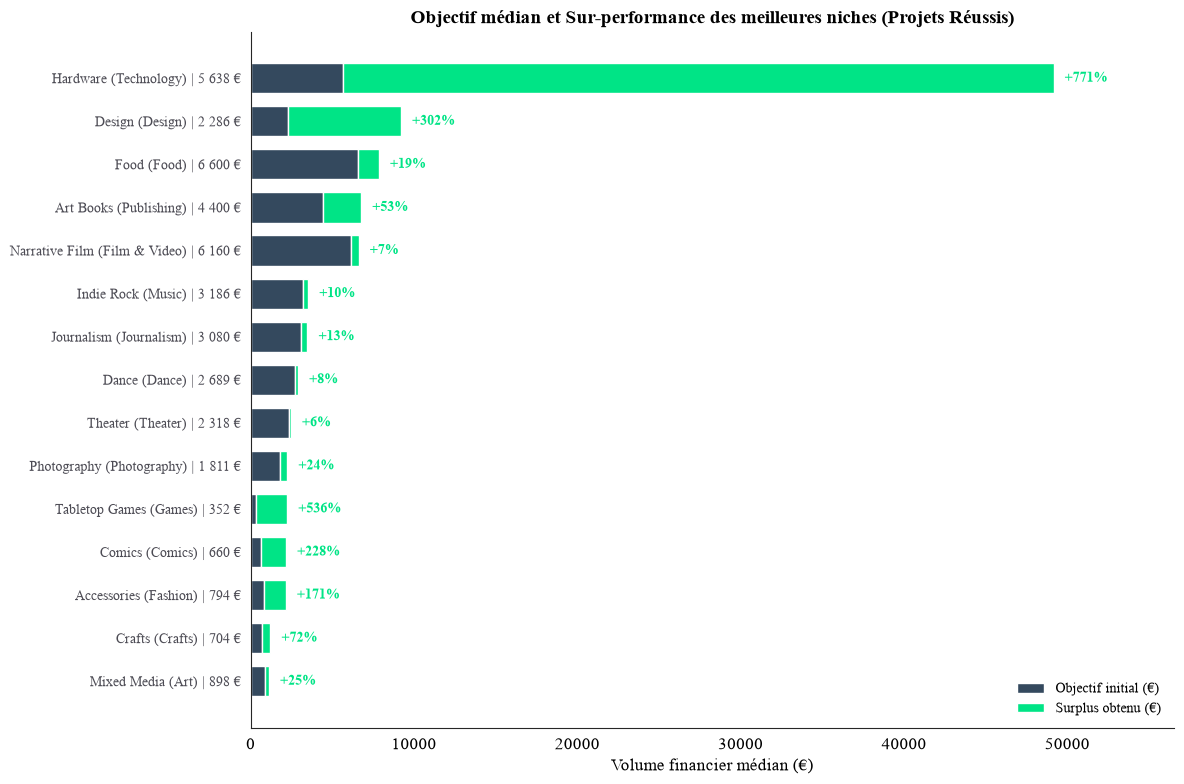

In [41]:
subcat_success = df_completed.groupby(['main_category', 'sub_category'], observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

subcat_funding = df_success.groupby(['main_category', 'sub_category'], observed=False).agg(
    median_funded=('percent_funded', 'median'),
    median_goal=('goal_eur', 'median')
).reset_index()

subcat_stats = pd.merge(subcat_success, subcat_funding, on=['main_category', 'sub_category'])
subcat_stats = subcat_stats[subcat_stats['volume'] >= 30]

subcat_stats = subcat_stats.sort_values(['main_category', 'success_rate'], ascending=[True, False])
best_niches = subcat_stats.groupby('main_category', observed=False).head(1).copy()

best_niches['label'] = best_niches.apply(
    lambda x: f"{x['sub_category']} ({x['main_category']}) | {int(x['median_goal']):,} €".replace(',', ' '), 
    axis=1
)

best_niches['surplus_pct'] = best_niches['median_funded'] - 100
best_niches['surplus_eur'] = best_niches['median_goal'] * (best_niches['surplus_pct'] / 100)
best_niches['total_eur'] = best_niches['median_goal'] + best_niches['surplus_eur']

best_niches = best_niches.sort_values('total_eur', ascending=True)

plt.figure(figsize=(12, 8))

y_positions = range(len(best_niches))
labels = best_niches['label']

plt.barh(
    y_positions, 
    best_niches['median_goal'], 
    color='#34495e', 
    label="Objectif initial (€)",
    height=0.7
)

plt.barh(
    y_positions, 
    best_niches['surplus_eur'], 
    left=best_niches['median_goal'], 
    color='#00e486', 
    label="Surplus obtenu (€)",
    height=0.7
)

# Annotations (Restauration du style typographique)
for i in range(len(best_niches)):
    surplus_pct = best_niches['surplus_pct'].iloc[i]
    total_eur = best_niches['total_eur'].iloc[i]
    
    if surplus_pct > 0:
        plt.annotate(
            f"+{int(surplus_pct)}%",
            (total_eur, i),
            xytext=(8, 0), textcoords='offset points',
            ha='left', va='center',
            fontsize=10, fontweight='bold', color='#00e486'
        )

plt.yticks(y_positions, labels, fontsize=10, color='#4c4b54') 
plt.title("Objectif médian et Sur-performance des meilleures niches (Projets Réussis)")
plt.xlabel("Volume financier médian (€)")
plt.ylabel("")

plt.xlim(0, best_niches['total_eur'].max() * 1.15)
plt.xticks()

sns.despine()
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

## Géographie

### Répartition mondiale
* D'où viennent la majorité des projets ?

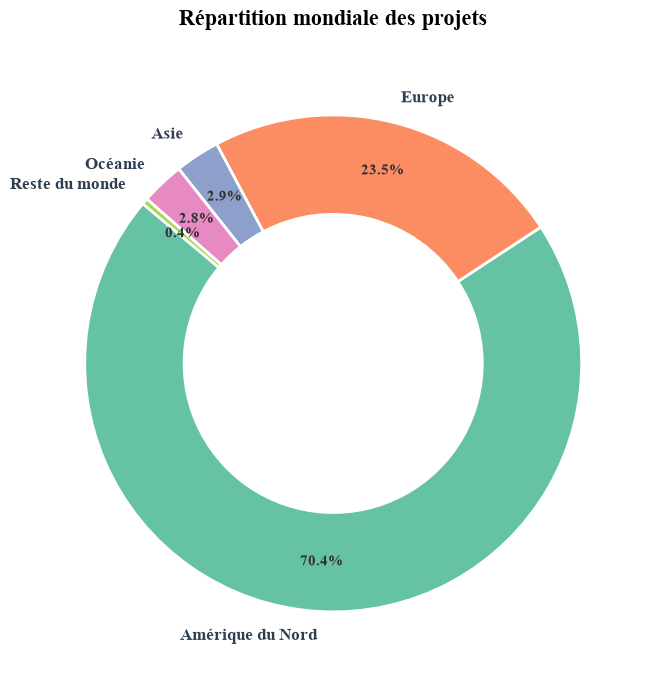

In [42]:
region_counts = kickstarter_df['region'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))

colors = sns.color_palette('Set2')[0:len(region_counts)]

wedges, texts, autotexts = ax.pie(
    region_counts, 
    labels=region_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=colors,
    pctdistance=0.80, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
plt.setp(texts, fontsize=12, fontweight='bold', color='#2c3e50')
plt.setp(autotexts, fontsize=11, fontweight='bold', color='#333333')

plt.title("Répartition mondiale des projets", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### Taux de succès géographique
* Certaines régions/pays performent-ils mieux que d'autres sur Kickstarter ?

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/2877463792.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


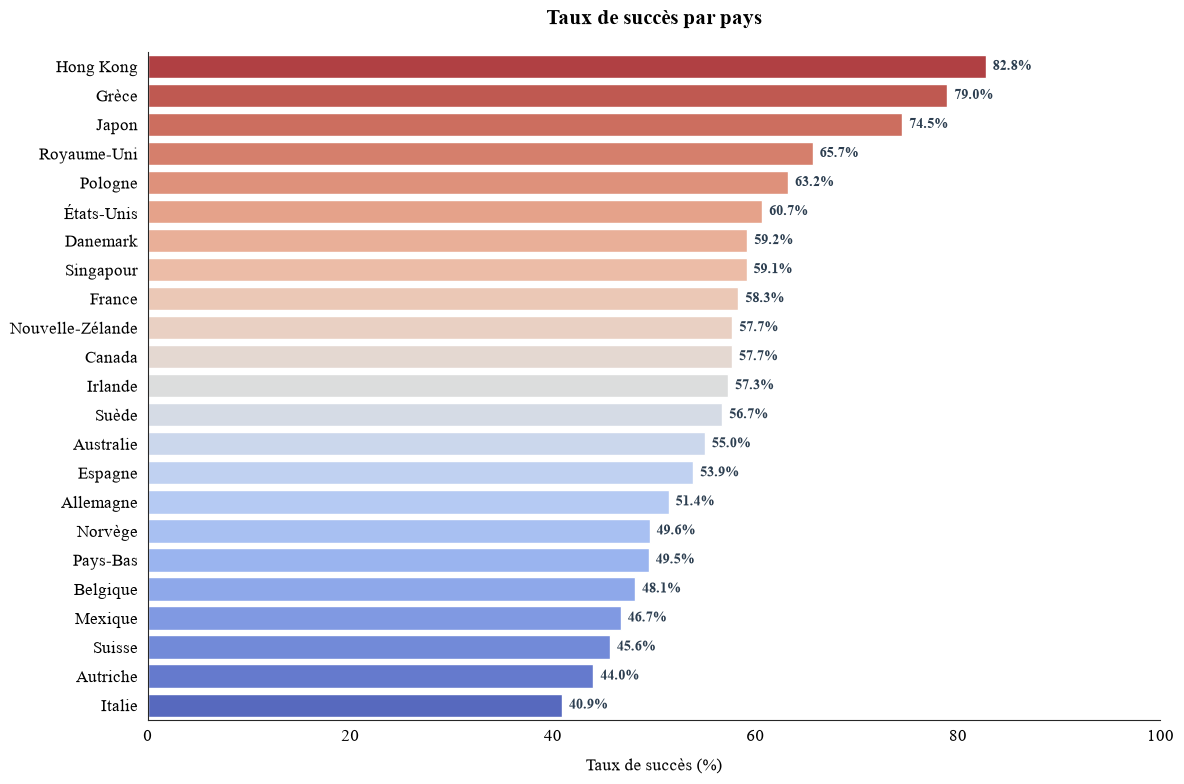

In [43]:
country_stats = df_completed.groupby('country').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

country_stats = country_stats[country_stats['volume'] >= 100]
country_stats = country_stats.sort_values('success_rate', ascending=False)


plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    data=country_stats, 
    x='success_rate', 
    y='country', 
    palette='coolwarm_r'
)

plt.title("Taux de succès par pays", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Taux de succès (%)", fontsize=12, labelpad=10)
plt.ylabel("")
plt.xlim(0, 100)

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/3472096996.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


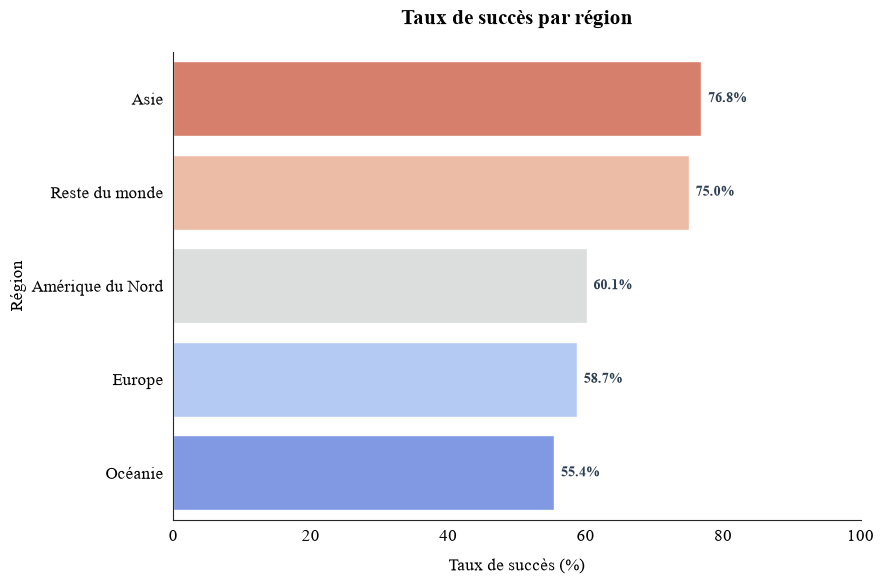

In [44]:
region_stats = df_completed.groupby('region').agg(
    success_rate=('is_success', lambda x: x.mean() * 100),
    volume=('is_success', 'count')
).reset_index()

region_stats = region_stats.sort_values('success_rate', ascending=False)
region_stats = region_stats[region_stats['volume'] >= 100]

plt.figure(figsize=(9, 6))
barplot = sns.barplot(
    data=region_stats, 
    x='success_rate', 
    y='region', 
    palette='coolwarm_r'
)

plt.title("Taux de succès par région", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Taux de succès (%)", fontsize=12, labelpad=10)
plt.ylabel("Région", fontsize=12)
plt.xlim(0, 100)

for p in barplot.patches:
    width = p.get_width()
    plt.annotate(f"{width:.1f}%",
                 (width, p.get_y() + p.get_height() / 2),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

## Signal et leviers marketing

### Media
* Impact direct de la vidéo explicative et de la phase de pré-lancement sur la réussite.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/2677268889.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=video_stats, x='has_video', y='success_rate', palette=['#ec136f', '#00e486'], ax=ax1)
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/2677268889.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prelaunch_stats, x='prelaunch_activated', y='success_rate', palette=['#ec136f', '#00e486'], ax=ax2)


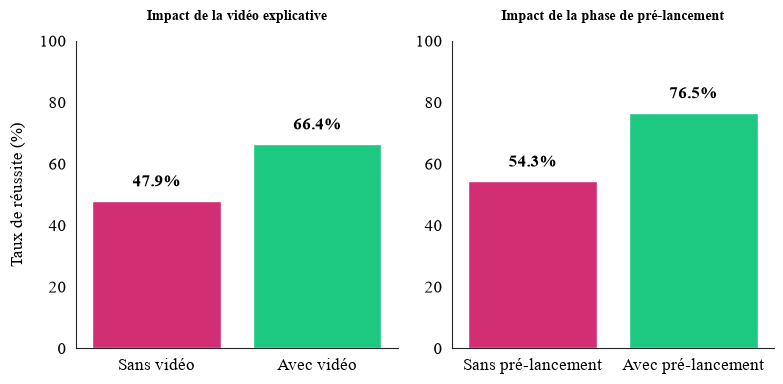

In [45]:
video_stats = df_completed.groupby('has_video').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

video_stats['has_video'] = video_stats['has_video'].replace({True: 'Avec vidéo', False: 'Sans vidéo', 1: 'Avec vidéo', 0: 'Sans vidéo'})

prelaunch_stats = df_completed.groupby('prelaunch_activated').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

prelaunch_stats['prelaunch_activated'] = prelaunch_stats['prelaunch_activated'].replace({True: 'Avec pré-lancement', False: 'Sans pré-lancement', 1: 'Avec pré-lancement', 0: 'Sans pré-lancement'})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))


sns.barplot(data=video_stats, x='has_video', y='success_rate', palette=['#ec136f', '#00e486'], ax=ax1)
ax1.set_title("Impact de la vidéo explicative", fontsize=10, fontweight='bold', pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Taux de réussite (%)", fontsize=12, labelpad=10)
ax1.set_ylim(0, 100)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=12, fontweight='bold')


sns.barplot(data=prelaunch_stats, x='prelaunch_activated', y='success_rate', palette=['#ec136f', '#00e486'], ax=ax2)
ax2.set_title("Impact de la phase de pré-lancement", fontsize=10, fontweight='bold', pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_ylim(0, 100)

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

La présence d'une vidéo de présentation ou la création d'une page de pré-lancement améliorent le signal envoyé aux futurs contributeurs, augmentant les chances de réussite.

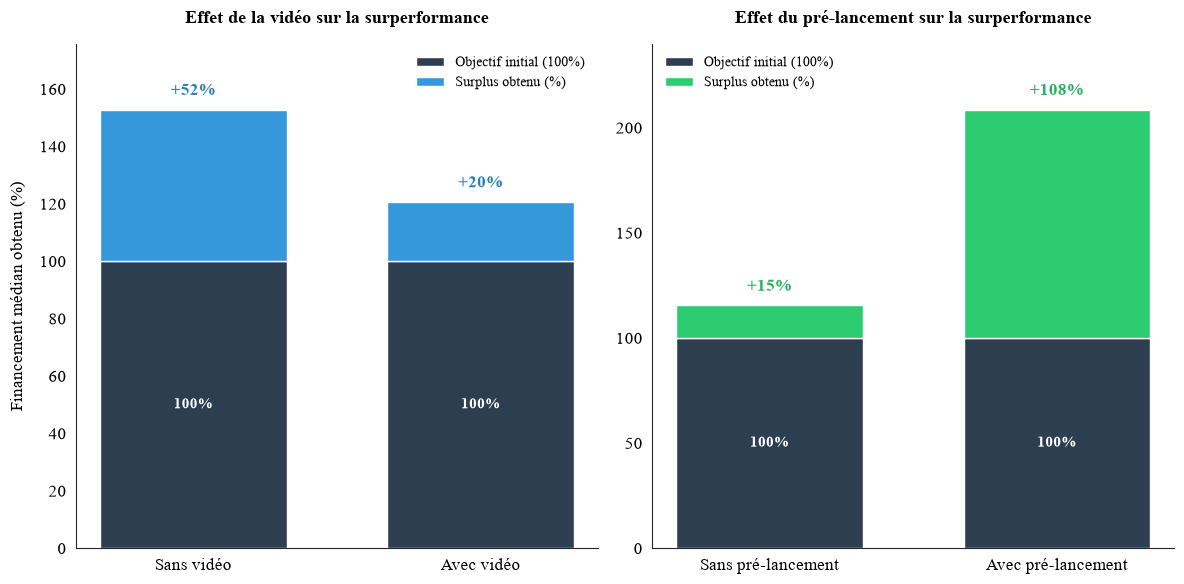

In [46]:
video_perf = df_success.groupby('has_video').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

video_perf['has_video'] = video_perf['has_video'].replace({
    True: 'Avec vidéo', False: 'Sans vidéo', 1: 'Avec vidéo', 0: 'Sans vidéo'
})

video_perf['has_video'] = pd.Categorical(video_perf['has_video'], categories=['Sans vidéo', 'Avec vidéo'], ordered=True)
video_perf = video_perf.sort_values('has_video')


prelaunch_perf = df_success.groupby('prelaunch_activated').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

prelaunch_perf['prelaunch_activated'] = prelaunch_perf['prelaunch_activated'].replace({
    True: 'Avec pré-lancement', False: 'Sans pré-lancement', 1: 'Avec pré-lancement', 0: 'Sans pré-lancement'
})

prelaunch_perf['prelaunch_activated'] = pd.Categorical(prelaunch_perf['prelaunch_activated'], categories=['Sans pré-lancement', 'Avec pré-lancement'], ordered=True)
prelaunch_perf = prelaunch_perf.sort_values('prelaunch_activated')

video_perf['base_100'] = 100
video_perf['surplus_pct'] = video_perf['median_funded'] - 100

prelaunch_perf['base_100'] = 100
prelaunch_perf['surplus_pct'] = prelaunch_perf['median_funded'] - 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
bar_width = 0.65


ax1.bar(video_perf['has_video'], video_perf['base_100'], color='#2c3e50', width=bar_width, label="Objectif initial (100%)")

ax1.bar(video_perf['has_video'], video_perf['surplus_pct'], bottom=video_perf['base_100'], color='#3498db', width=bar_width, label="Surplus obtenu (%)")

ax1.set_title("Effet de la vidéo sur la surperformance", fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel("Financement médian obtenu (%)", fontsize=12, labelpad=10)
ax1.set_ylim(0, video_perf['median_funded'].max() * 1.15)
ax1.legend(loc='upper right', frameon=False)


for i in range(len(video_perf)):
    base = video_perf['base_100'].iloc[i]
    surplus = video_perf['surplus_pct'].iloc[i]
    total = video_perf['median_funded'].iloc[i]
    
   
    ax1.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    if surplus > 0:
        ax1.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2980b9')


ax2.bar(prelaunch_perf['prelaunch_activated'], prelaunch_perf['base_100'], color='#2c3e50', width=bar_width, label="Objectif initial (100%)")
# Surplus
ax2.bar(prelaunch_perf['prelaunch_activated'], prelaunch_perf['surplus_pct'], bottom=prelaunch_perf['base_100'], color='#2ecc71', width=bar_width, label="Surplus obtenu (%)")

ax2.set_title("Effet du pré-lancement sur la surperformance", fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, prelaunch_perf['median_funded'].max() * 1.15)
ax2.legend(loc='upper left', frameon=False)

for i in range(len(prelaunch_perf)):
    base = prelaunch_perf['base_100'].iloc[i]
    surplus = prelaunch_perf['surplus_pct'].iloc[i]
    total = prelaunch_perf['median_funded'].iloc[i]
    
    # Texte du socle
    ax2.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    # Texte du surplus
    if surplus > 0:
        ax2.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#27ae60')


sns.despine()
plt.tight_layout()
plt.show()

En revanche les projets qui ont des vidéos ont moins de chances de sur-performer, tandis que l'activation d'une page de pré-lancement double la performance médiane.

### Recommandation de Kickstarter
* L'effet "Coup de cœur Kickstarter" sur le succès et la surperformance

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/3741150465.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=staff_success_stats, x='staff_pick_label', y='success_rate', palette=palette_staff, ax=ax1)


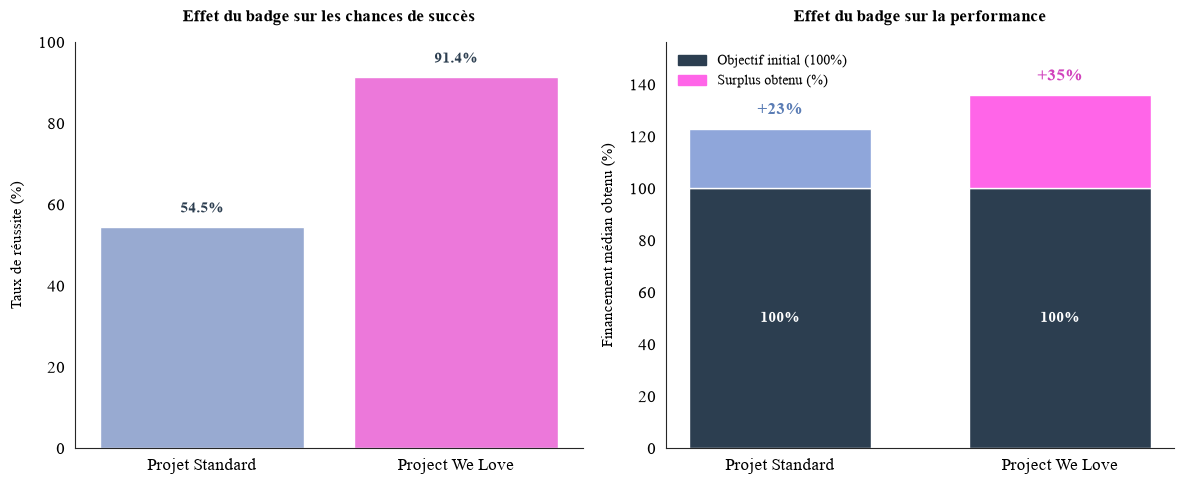

In [47]:
import matplotlib.patches as mpatches


labels_dict = {True: 'Project We Love', False: 'Projet Standard', 1: 'Project We Love', 0: 'Projet Standard'}


staff_success_stats = df_completed.groupby('staff_pick').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

staff_success_stats['staff_pick_label'] = staff_success_stats['staff_pick'].map(labels_dict)
staff_success_stats['staff_pick_label'] = pd.Categorical(staff_success_stats['staff_pick_label'], categories=['Projet Standard', 'Project We Love'], ordered=True)
staff_success_stats = staff_success_stats.sort_values('staff_pick_label')


staff_funded_stats = df_success.groupby('staff_pick').agg(
    median_funded=('percent_funded', 'median')
).reset_index()

staff_funded_stats['staff_pick_label'] = staff_funded_stats['staff_pick'].map(labels_dict)
staff_funded_stats['staff_pick_label'] = pd.Categorical(staff_funded_stats['staff_pick_label'], categories=['Projet Standard', 'Project We Love'], ordered=True)
staff_funded_stats = staff_funded_stats.sort_values('staff_pick_label')


staff_funded_stats['base_100'] = 100
staff_funded_stats['surplus_pct'] = staff_funded_stats['median_funded'] - 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
palette_staff = ['#8fa6da', '#ff65e8'] 
bar_width = 0.65

sns.barplot(data=staff_success_stats, x='staff_pick_label', y='success_rate', palette=palette_staff, ax=ax1)
ax1.set_title("Effet du badge sur les chances de succès", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Taux de réussite (%)", fontsize=11, labelpad=10)
ax1.set_ylim(0, 100)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

ax2.bar(staff_funded_stats['staff_pick_label'], staff_funded_stats['base_100'], color='#2c3e50', width=bar_width)

ax2.bar(staff_funded_stats['staff_pick_label'], staff_funded_stats['surplus_pct'], bottom=staff_funded_stats['base_100'], color=palette_staff, width=bar_width)

ax2.set_title("Effet du badge sur la performance", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("Financement médian obtenu (%)", fontsize=11, labelpad=10)
ax2.set_ylim(0, staff_funded_stats['median_funded'].max() * 1.15)


patch_base = mpatches.Patch(color='#2c3e50', label='Objectif initial (100%)')
patch_surplus = mpatches.Patch(color='#ff65e8', label='Surplus obtenu (%)')
ax2.legend(handles=[patch_base, patch_surplus], loc='upper left', frameon=False)

for i in range(len(staff_funded_stats)):
    base = staff_funded_stats['base_100'].iloc[i]
    surplus = staff_funded_stats['surplus_pct'].iloc[i]
    total = staff_funded_stats['median_funded'].iloc[i]
    
    
    ax2.annotate("100%", (i, base / 2), ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
  
    if surplus > 0:
        
        text_color = '#5b7db5' if i == 0 else '#d143bd' 
        
        ax2.annotate(f"+{int(surplus)}%", (i, total), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=12, fontweight='bold', color=text_color)

sns.despine()
plt.tight_layout()
plt.show()

La recommandation de Kickstarter est un signal de preuve sociale pour les contributeurs : elle double les chances de réussite et augmente légèrement la performance médiane.

### Influence de la recommandation de Kickstarter sur la traction de contributeurs

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/2671676496.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/2671676496.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


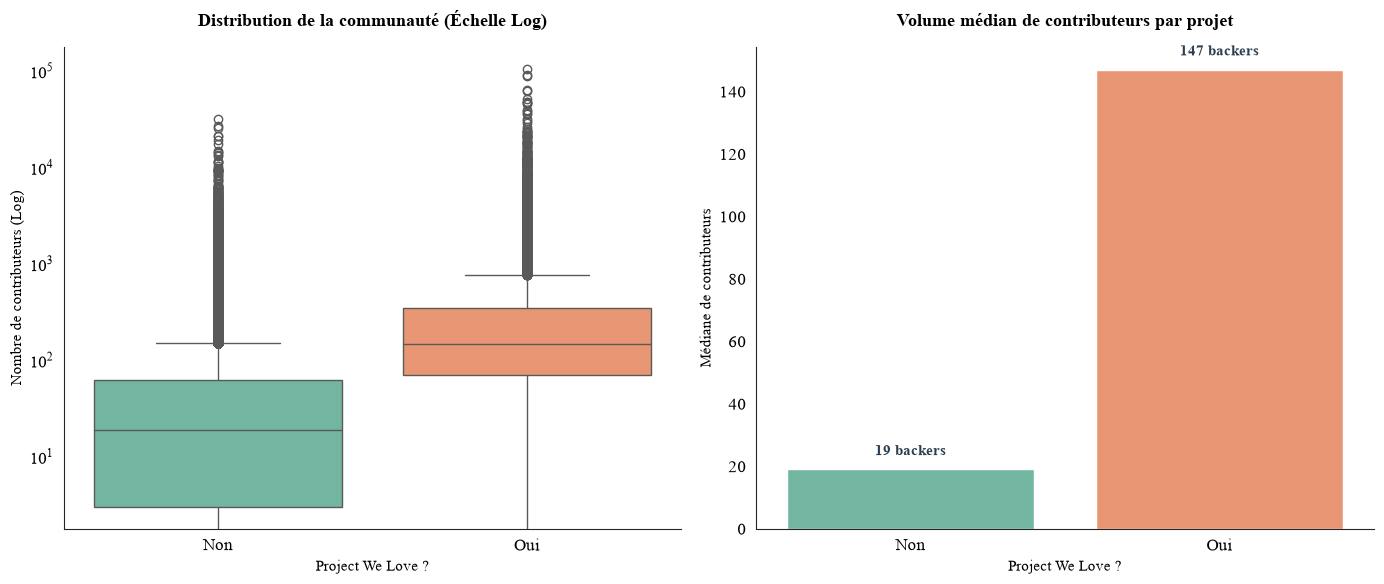

In [48]:
df_completed['staff_pick_label'] = df_completed['staff_pick'].map({True: 'Oui', False: 'Non'})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_completed, 
    x='staff_pick_label', 
    y='backers_count', 
    palette='Set2', 
    ax=ax1
)
ax1.set_yscale('log')
ax1.set_title("Distribution de la communauté (Échelle Log)", fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Project We Love ?", fontsize=11)
ax1.set_ylabel("Nombre de contributeurs (Log)", fontsize=11)

median_backers = df_completed.groupby('staff_pick_label', observed=True)['backers_count'].median().reset_index()

barplot = sns.barplot(
    data=median_backers, 
    x='staff_pick_label', 
    y='backers_count', 
    palette='Set2', 
    ax=ax2
)
ax2.set_title("Volume médian de contributeurs par projet", fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Project We Love ?", fontsize=11)
ax2.set_ylabel("Médiane de contributeurs", fontsize=11)

# Ajout des valeurs exactes sur le barplot
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())} backers",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                 fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

On comprend que le label Staff Pick a l'air d'avoir une influence sur le nombre de backers par projet. Obtenir le label change radicalement la dimension de la communauté attendue pour n'importe quel type de campagne.

### Typologie de soutien des projets avec le badge Projects We Love

Les projets qui ont le badge attirent-il des contributeurs plus qualitatifs ?

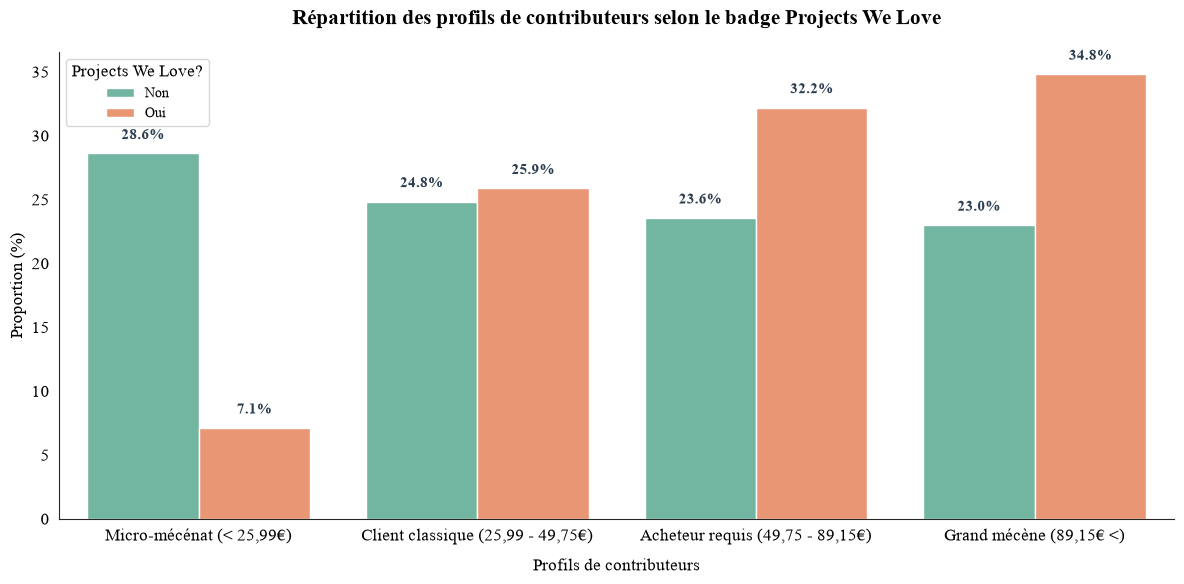

In [49]:
df_completed = kickstarter_df[kickstarter_df['state'].isin(['successful', 'failed', 'canceled'])].copy()

df_completed['staff_pick_label'] = df_completed['staff_pick'].map({True: 'Oui', False: 'Non'})

df_filtered = df_completed[df_completed['backer_profile_qcut'].isin(ordre_qcut)]


prop_df = df_filtered.groupby(['staff_pick_label', 'backer_profile_qcut']).size().reset_index(name='count')
prop_df['proportion'] = prop_df.groupby('staff_pick_label')['count'].transform(lambda x: x / x.sum() * 100)


plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=prop_df,
    x='backer_profile_qcut',
    y='proportion',
    hue='staff_pick_label',
    palette='Set2',
    order=ordre_qcut
)


plt.title("Répartition des profils de contributeurs selon le badge Projects We Love", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Profils de contributeurs", fontsize=12, labelpad=10)
plt.ylabel("Proportion (%)", fontsize=12)
plt.legend(title="Projects We Love?", loc='upper left')


for p in barplot.patches:
    if p.get_height() > 0:
        plt.annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 8), textcoords='offset points',
                     fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()
plt.tight_layout()
plt.show()

Le graphique nous montre en effet que le label Staff Pick attire des contributeurs qui ont un panier moyen beaucoup plus élevé que les projets qui n'ont pas le label.

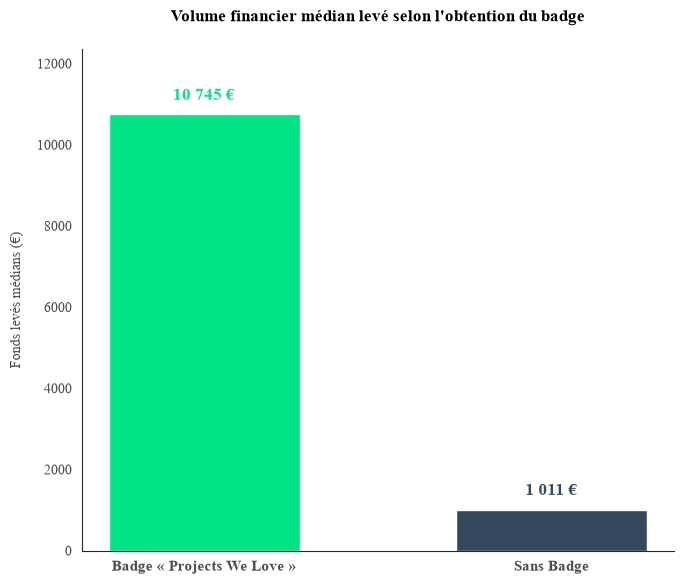

In [ ]:

staff_pick_stats = df_completed.groupby('staff_pick', observed=False).agg(
    median_pledged=('pledged_eur', 'median')
).reset_index()

staff_pick_stats['staff_pick_label'] = staff_pick_stats['staff_pick'].map({
    True: "Badge « Projects We Love »",
    False: "Sans Badge"
})

staff_pick_stats = staff_pick_stats.sort_values('median_pledged', ascending=False)

plt.figure(figsize=(7, 6))

colors = ['#00e486' if val == True else '#34495e' for val in staff_pick_stats['staff_pick']]

bars = plt.bar(
    staff_pick_stats['staff_pick_label'], 
    staff_pick_stats['median_pledged'], 
    color=colors,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{int(height):,} €".replace(',', ' '),
        (bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 8),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color=bar.get_facecolor()
    )

plt.title("Volume financier médian levé selon l'obtention du badge", fontsize=12, fontweight='bold', color='#000000', pad=20)
plt.ylabel("Fonds levés médians (€)", fontsize=10, color='#4c4b54', labelpad=10)
plt.xlabel("")

plt.ylim(0, staff_pick_stats['median_pledged'].max() * 1.15)

plt.xticks(fontsize=11, fontweight='bold', color='#4c4b54')
plt.yticks(fontsize=10, color='#4c4b54')

sns.despine()
plt.tight_layout()
plt.show()

### Optimisation du titre et de la description
* Impact de la longueur du nom et du blurb sur le taux de succès.

/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_3504/600850626.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats, x='label', y='su

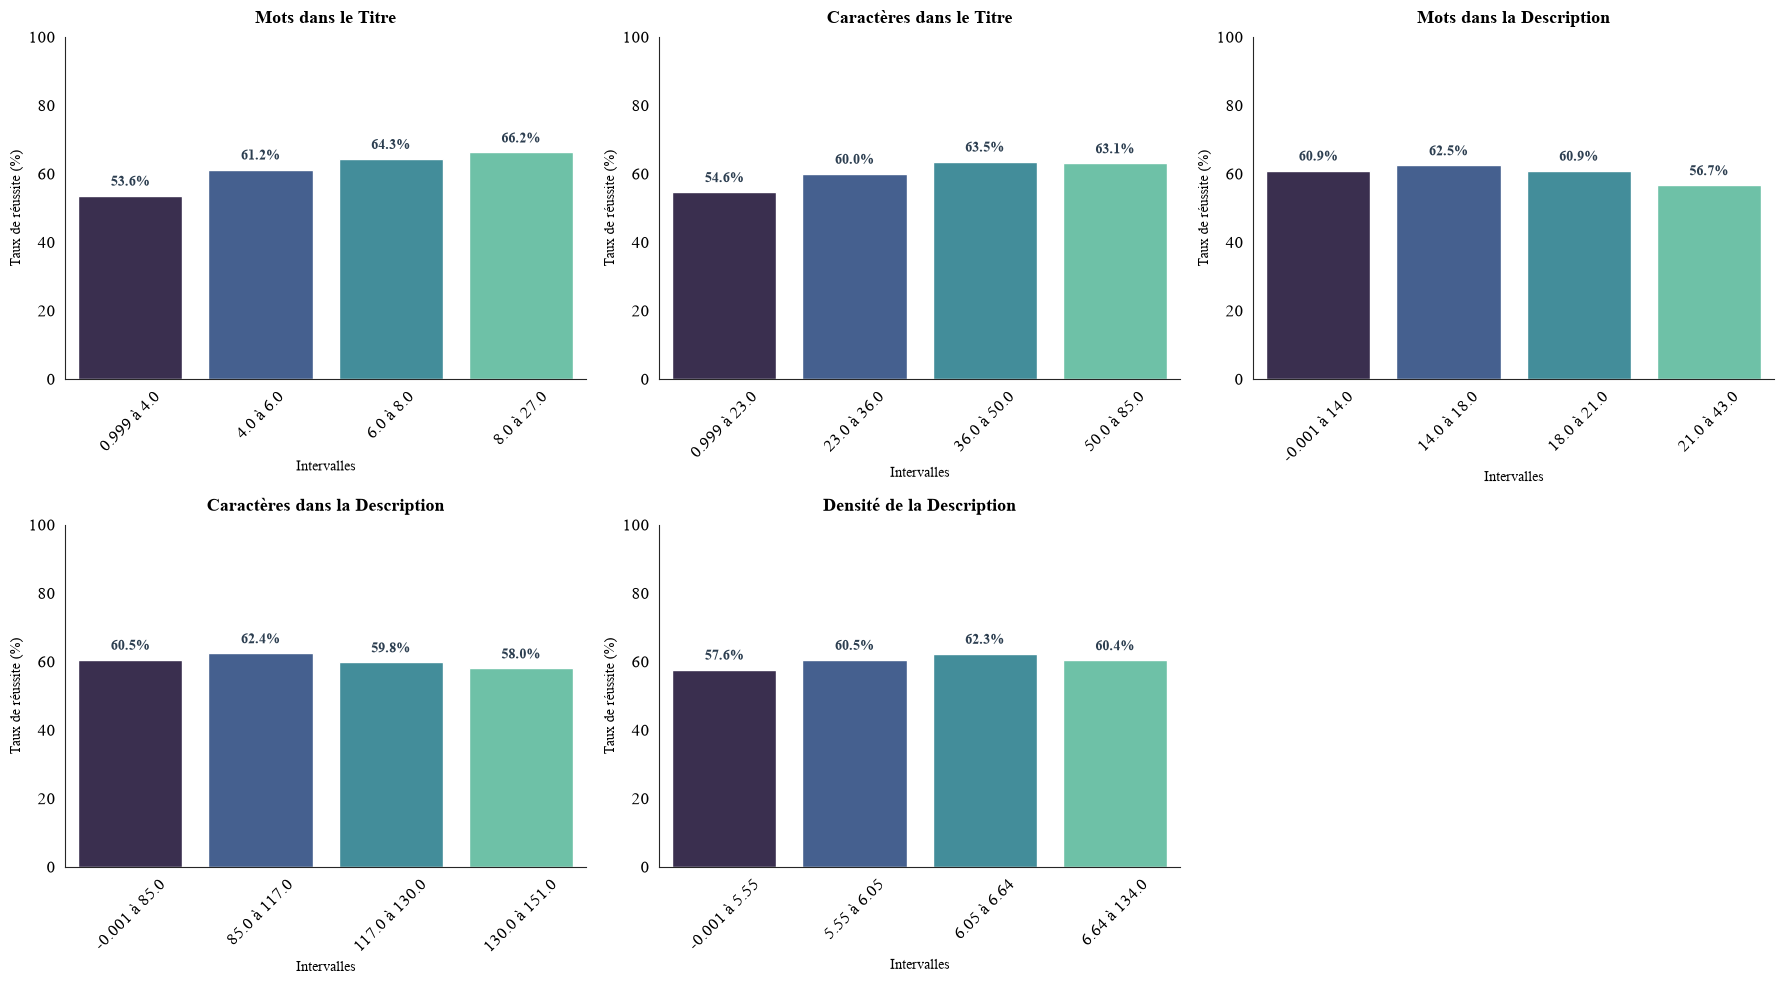

In [ ]:
text_features = ['name_len_words', 'name_len_char', 'blurb_len_words', 'blurb_len_char', 'blurb_density']
titles = ['Mots dans le Titre', 'Caractères dans le Titre', 'Mots dans la Description', 'Caractères dans la Description', 'Densité de la Description']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(text_features):
    df_completed[f'{feature}_bins'] = pd.qcut(df_completed[feature], q=4, duplicates='drop')
    
    stats = df_completed.groupby(f'{feature}_bins', observed=True).agg(
        success_rate=('is_success', lambda x: x.mean() * 100)
    ).reset_index()
    
    stats['label'] = stats[f'{feature}_bins'].astype(str).str.replace('(', '', regex=False)\
                                                         .str.replace(']', '', regex=False)\
                                                         .str.replace(', ', ' à ', regex=False)
    
    sns.barplot(data=stats, x='label', y='success_rate', ax=axes[i], palette='mako')
    
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Intervalles", fontsize=10)
    axes[i].set_ylabel("Taux de réussite (%)", fontsize=10)
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)

    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                     fontsize=10, fontweight='bold', color='#2c3e50')

axes[5].axis('off')

sns.despine()
plt.tight_layout()
plt.show()

* Pour le titre, plus c'est long, plus c'est bon. On note un escalier sur la longueur des mots et des caractères. Le titre doit être descriptif, pas mystérieux. Il doit montrer la proposition de valeur.
* Pour le blurb, il faut viser entre 14 à 18 mots pour maximiser ses chances. Si le texte est trop minimaliste, il manque d'arguments. Mais si il est trop verbeux, l'attention chute.
* Quant à la densité de la description qui reflète la taille moyenne des mots utilisés, elle montre qu'il faut privilégier un vocabulaire professionnel et précis, mais pas trop jargonneux non plus.

**Pour résumer, le signal idéal combine un titre très descriptif pour attirer le clic et un résumé percutant et concis pour convertir rapidement.**